# 📎 0. Importación de los CVSs y lectura

##⬇️ Importación

In [1]:
#Importación de librerías
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import seaborn as sns
from geopy.geocoders import Nominatim
from time import sleep
import folium

In [2]:
#Importación de los csv
from google.colab import files
uploaded = files.upload()

Saving barrios.csv to barrios.csv
Saving ciudades.csv to ciudades.csv
Saving dataset_inmobiliario_imperfecto.csv to dataset_inmobiliario_imperfecto.csv
Saving tipos_inmueble.csv to tipos_inmueble.csv


## 📖 Lectura

In [3]:
#Lectura con pandas
import pandas as pd

df_barrios = pd.read_csv('/content/barrios.csv')
df_ciudades = pd.read_csv ('/content/ciudades.csv')
df_inmobiliario = pd.read_csv ('/content/dataset_inmobiliario_imperfecto.csv')
df_tipo = pd.read_csv ('/content/tipos_inmueble.csv')

In [4]:
df_barrios.head()

,ciudad,barrio,distrito,renta_media,precio_m2_barrio,latitud_barrio,longitud_barrio,num_colegios,num_centros_salud,num_estaciones_transp,num_zonas_verdes,nivel_servicios,indice_seguridad,indice_contaminacion,indice_accesibilidad
0,Madrid,Salamanca,Centro,28477.0,6356.0,40.4207,-3.7176,1,3,3,1,Medio,6.3,3.1,8.4
1,Madrid,Chamberí,Centro,30715.0,5036.0,40.4085,-3.7091,2,1,0,1,Bajo,4.2,6.1,6.6
2,Madrid,Retiro,Norte,20788.0,3372.0,40.4166,-3.7224,3,1,7,1,Alto,9.3,5.5,4.6
3,Madrid,Centro,Periférico,30416.0,5648.0,40.4080,-3.7021,1,0,3,4,Medio,5.7,5.7,6.5
4,Madrid,Tetuán,Periférico,27319.0,5002.0,40.3993,-3.7114,3,1,6,0,Alto,8.0,4.9,8.6


In [5]:
df_ciudades.head()

,ciudad,comunidad_autonoma,poblacion,superficie_km2,precio_m2_medio,latitud_centro,longitud_centro
0,Madrid,Madrid,3300000,604.3,5000,40.4168,-3.7038
1,Barcelona,Cataluña,1600000,101.9,4500,41.3851,2.1734
2,Valencia,Comunidad Valenciana,800000,134.6,3000,39.4699,-0.3763
3,Sevilla,Andalucía,700000,140.0,3200,37.3891,-5.9845
4,Bilbao,País Vasco,345000,41.6,4000,43.2630,-2.9350


In [6]:
df_inmobiliario.head()

,id_propiedad,ciudad,barrio,tipo_operacion,tipo_inmueble,precio,superficie_m2,habitaciones,baños,estado,año_construccion,planta,ascensor,terraza,piscina,garaje,trastero,distancia_centro_km,fecha_publicacion
0,1,Madrid,Arganzuela,Venta,Estudio,NaN,57.800000,3.0,1.0,Buen estado,2000,2,True,True,False,False,True,4.10,2024-11-04
1,2,Madrid,Arganzuela,Alquiler,Piso,NaN,NaN,3.0,1.0,Buen estado,1996,Bajo,True,True,False,False,True,5.26,2024-10-16
2,3,Madrid,Salamanca,Venta,Piso,821455.0,153.978185,2.0,1.0,Buen estado,1996,3,False,True,False,False,False,5.13,2025-03-24
3,4,Madrid,Arganzuela,Venta,Piso,337577.0,74.000000,4.0,2.0,Buen estado,1945,Bajo,True,True,False,False,False,5.52,2024-11-18
4,5,Madrid,Arganzuela,Venta,Piso,394652.0,82.000000,3.0,1.0,Buen estado,1981,5,True,False,NaN,False,True,5.97,2024-11-04


In [7]:
df_tipo.head()

,tipo_inmueble,descripcion
0,Piso,"Apartamento en edificio, usualmente con varias..."
1,Estudio,"Vivienda de planta única, generalmente compacta."
2,Dúplex,Apartamento de dos niveles comunicados mediant...
3,Ático,"Piso en la última planta, con vistas y terraza."
4,Chalet,"Casa independiente, a menudo con jardín y mayo..."


#📎 1. EDA BARRIOS

## 🔍 1.1. Carga y comprensión inicial del dataset

Vamos a visualizar el df de Barrios. Para ello, vamos a:
- Ver una muestra con el .head() con el objetivo de ver las columnas del dataframe y los valores que nos podemos encontrar dentro de él.
- Ver la cantidad de filas y columnas con el .shape.
- Ver un resumen con la información de las columnas, para ver el tipo de datos y si hay nulos en cada una de ellas, con el .info().
- Ver un .describe() para ver las estadísticas básicas de los datos.

In [8]:
df_barrios.head()

,ciudad,barrio,distrito,renta_media,precio_m2_barrio,latitud_barrio,longitud_barrio,num_colegios,num_centros_salud,num_estaciones_transp,num_zonas_verdes,nivel_servicios,indice_seguridad,indice_contaminacion,indice_accesibilidad
0,Madrid,Salamanca,Centro,28477.0,6356.0,40.4207,-3.7176,1,3,3,1,Medio,6.3,3.1,8.4
1,Madrid,Chamberí,Centro,30715.0,5036.0,40.4085,-3.7091,2,1,0,1,Bajo,4.2,6.1,6.6
2,Madrid,Retiro,Norte,20788.0,3372.0,40.4166,-3.7224,3,1,7,1,Alto,9.3,5.5,4.6
3,Madrid,Centro,Periférico,30416.0,5648.0,40.4080,-3.7021,1,0,3,4,Medio,5.7,5.7,6.5
4,Madrid,Tetuán,Periférico,27319.0,5002.0,40.3993,-3.7114,3,1,6,0,Alto,8.0,4.9,8.6


In [9]:
df_barrios.tail()

,ciudad,barrio,distrito,renta_media,precio_m2_barrio,latitud_barrio,longitud_barrio,num_colegios,num_centros_salud,num_estaciones_transp,num_zonas_verdes,nivel_servicios,indice_seguridad,indice_contaminacion,indice_accesibilidad
28,Málaga,El Palo,NaN,16717.0,4019.0,36.7152,-4.4208,5,2,4,1,Alto,3.4,5.3,7.7
29,Zaragoza,Centro,NaN,30232.0,5968.0,41.6555,-0.9022,1,0,1,0,Bajo,6.1,6.8,5.4
30,Zaragoza,La Romareda,NaN,21124.0,4232.0,41.6564,-0.9075,2,2,3,1,Medio,4.7,10.0,6.5
31,Zaragoza,Delicias,NaN,20614.0,4633.0,41.6303,-0.8990,4,1,2,0,Medio,3.2,5.4,6.0
32,Zaragoza,San José,NaN,19587.0,4682.0,41.6525,-0.8819,2,1,2,1,Medio,6.0,8.4,9.9


In [10]:
df_barrios.sample(5)

,ciudad,barrio,distrito,renta_media,precio_m2_barrio,latitud_barrio,longitud_barrio,num_colegios,num_centros_salud,num_estaciones_transp,num_zonas_verdes,nivel_servicios,indice_seguridad,indice_contaminacion,indice_accesibilidad
15,Valencia,Campanar,NaN,32336.0,5726.0,39.4675,-0.3932,0,3,1,2,Medio,5.6,5.1,8.4
17,Sevilla,Nervión,NaN,18511.0,3687.0,37.3880,-5.9976,2,1,5,0,Medio,6.4,6.7,7.1
6,Barcelona,Eixample,Centro,33916.0,8007.0,41.3654,2.1738,1,0,4,3,Medio,6.1,4.1,7.0
25,Málaga,Centro,NaN,28999.0,4821.0,36.7377,-4.4085,6,0,3,5,Alto,8.0,4.6,6.1
16,Sevilla,Triana,NaN,39855.0,7651.0,37.3790,-5.9903,1,0,0,0,Bajo,8.0,7.7,8.2


In [11]:
df_barrios.shape

(33, 15)

In [12]:
df_barrios.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33 entries, 0 to 32
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ciudad                 33 non-null     object 
 1   barrio                 33 non-null     object 
 2   distrito               11 non-null     object 
 3   renta_media            33 non-null     float64
 4   precio_m2_barrio       33 non-null     float64
 5   latitud_barrio         33 non-null     float64
 6   longitud_barrio        33 non-null     float64
 7   num_colegios           33 non-null     int64  
 8   num_centros_salud      33 non-null     int64  
 9   num_estaciones_transp  33 non-null     int64  
 10  num_zonas_verdes       33 non-null     int64  
 11  nivel_servicios        33 non-null     object 
 12  indice_seguridad       33 non-null     float64
 13  indice_contaminacion   33 non-null     float64
 14  indice_accesibilidad   33 non-null     float64
dtypes: float

In [13]:
df_barrios.describe().round(2)

,renta_media,precio_m2_barrio,latitud_barrio,longitud_barrio,num_colegios,num_centros_salud,num_estaciones_transp,num_zonas_verdes,indice_seguridad,indice_contaminacion,indice_accesibilidad
count,33.00,33.00,33.00,33.00,33.00,33.00,33.00,33.00,33.00,33.00,33.00
mean,27578.21,5548.12,40.00,-2.31,2.15,1.24,2.82,1.58,6.61,6.65,7.14
std,5770.26,1292.53,2.11,2.65,1.52,1.12,1.94,1.48,1.59,1.61,1.47
min,16717.00,3274.00,36.72,-6.00,0.00,0.00,0.00,0.00,3.20,3.10,4.20
25%,23543.00,4682.00,37.39,-4.41,1.00,0.00,1.00,0.00,5.80,5.50,6.10
50%,28313.00,5521.00,40.41,-2.94,2.00,1.00,3.00,1.00,6.50,6.70,7.10
75%,30715.00,6129.00,41.39,-0.38,3.00,2.00,4.00,3.00,7.80,7.50,8.40
max,39855.00,8190.00,43.27,2.19,6.00,4.00,7.00,5.00,10.00,10.00,10.00


##📊 1.2. Limpieza de los datos

###Estandarizar datos

Hacemos una estandarización de datos básica para evitar que haya valores erróneos y que nos puedan dar problemas en las agrupaciones.

In [14]:
def limpiar_inconsistencias(df_barrios):
    df_barrios.columns = (
        df_barrios.columns
        .str.strip()
        .str.lower()
        .str.replace(' ', '_')
        .str.replace(r'[^\w_]', '', regex=True)
    )

    for col in df_barrios.select_dtypes(include='object').columns:
        df_barrios[col] = (
            df_barrios[col]
            .where(df_barrios[col].isna(), df_barrios[col].str.strip().str.replace(r'\s+', ' ', regex=True))
        )

    return df_barrios

In [15]:
df_barrios = limpiar_inconsistencias(df_barrios)

###Tratamiento de los valores nulos

Vamos a empezar revisando los nulos del df, que como ya nos adelantaba el .info(), tenemos varios en la columna distrito.

In [16]:
df_barrios.isnull().sum()

,0
ciudad,0
barrio,0
distrito,22
renta_media,0
precio_m2_barrio,0
latitud_barrio,0
longitud_barrio,0
num_colegios,0
num_centros_salud,0
num_estaciones_transp,0


Antes de analizar a fondo los nulos de la columna "distrito", vamos a confirmar que la latitud y longitud coinciden con los barrios que hay en el dataframe.

###Corrección de barrios

In [17]:
#Imprimimos un mapa para ver si las coordenadas se corresponden con las ciudades del dataframe. Vemos efectivamente que ñps puntos no se corresponden con el barrio real.

mapa = folium.Map(location=[40.4168, -3.7038], zoom_start=7)

for i, row in df_barrios.iterrows():
    folium.Marker(
        location=[row['latitud_barrio'], row['longitud_barrio']],
        popup=f"{row['barrio']} - {row['ciudad']}",
        icon=folium.Icon(color="blue")
    ).add_to(mapa)

mapa

Haciendo una búsqueda de las coordenadas en el mapa, y clicando en los puntos exactos que pone en el df, vemos que no coinciden con los barrios de la columna "barrio". Vamos a explorar qué barrios corresponderían a esas coordenadas.

In [18]:
#Vamos a crear una lista formadas por tuplas con la latitud y longitud de cada columna del df:
coordenadas = list(zip(df_barrios['latitud_barrio'], df_barrios['longitud_barrio']))
coordenadas

[(40.4207, -3.7176),
 (40.4085, -3.7091),
 (40.4166, -3.7224),
 (40.408, -3.7021),
 (40.3993, -3.7114),
 (40.4132, -3.6936),
 (41.3654, 2.1738),
 (41.3762, 2.1897),
 (41.3856, 2.1625),
 (41.3748, 2.1571),
 (41.3741, 2.1819),
 (39.47, -0.3732),
 (39.484, -0.3845),
 (39.4643, -0.3846),
 (39.4514, -0.3634),
 (39.4675, -0.3932),
 (37.379, -5.9903),
 (37.388, -5.9976),
 (37.3846, -5.9788),
 (37.37, -5.9719),
 (37.3732, -5.9684),
 (43.2609, -2.9433),
 (43.2712, -2.9517),
 (43.2477, -2.929),
 (43.2682, -2.9272),
 (36.7377, -4.4085),
 (36.7391, -4.4074),
 (36.7234, -4.419),
 (36.7152, -4.4208),
 (41.6555, -0.9022),
 (41.6564, -0.9075),
 (41.6303, -0.899),
 (41.6525, -0.8819)]

In [19]:
geolocator = Nominatim(user_agent="proyecto_inmobiliario_2025")
barrios = []

for coord in coordenadas:
    try:
        location = geolocator.reverse(coord, language='es')
        barrio = location.raw['address'].get('neighbourhood') or location.raw['address'].get('suburb')
        barrios.append(barrio)
        sleep(1)
    except:
        barrios.append(None)

In [20]:
barrios

['Moncloa-Aravaca',
 'Lavapiés',
 'Moncloa-Aravaca',
 'Lavapiés',
 'Arganzuela',
 None,
 'la Marina del Prat Vermell',
 'Ciutat Vella',
 'Eixample',
 'Sants-Montjuïc',
 'Ciutat Vella',
 'Ciudad Vieja',
 'les Tendetes',
 'Arrancapins',
 'Ciudad de las Artes y las Ciencias',
 'Nou Moles',
 'Santa Cruz',
 'El Arenal',
 'Huerta del Pilar',
 'Felipe II-Los Diez Mandamientos',
 'El Juncal-Híspalis',
 'Autonomia',
 None,
 'San Adrián',
 None,
 'Los Antonios',
 'Sierra Blanquilla',
 'Centro Histórico',
 None,
 'La Almozara',
 'La Almozara',
 'Romareda',
 'El Tubo']

In [21]:
df_barrios['barrio'].unique().tolist()

['Salamanca',
 'Chamberí',
 'Retiro',
 'Centro',
 'Tetuán',
 'Arganzuela',
 'Eixample',
 'Gràcia',
 'Sants-Montjuïc',
 'Ciutat Vella',
 'Sarrià-Sant Gervasi',
 'Ruzafa',
 'El Carmen',
 'Ensanche',
 'Benimaclet',
 'Campanar',
 'Triana',
 'Nervión',
 'Los Remedios',
 'Macarena',
 'Santa Cruz',
 'Abando',
 'Indautxu',
 'Deusto',
 'Casco Viejo',
 'La Malagueta',
 'Pedregalejo',
 'El Palo',
 'La Romareda',
 'Delicias',
 'San José']

Vemos que las localizaciones exactas no coindicen con los barrios que están actualmente en el dataframe. De esta manera, vamos a considerar las columnas de "latitud" y "longitud" erróneas por los siguientes motivos:
- Este dataframe está montado en base a los barrios que ya están en el dataframe. De hecho, el dataframe de inmobiliario, vemos que tiene datos de estos mismos barrios, por lo que no tendría sentido que no coincidieran.
- Vemos que las coordenadas muestran barrios repetidos, de tal manera que habría datos duplicados con diferentes niveles e índices. Esto tampoco tiene sentido si este dataframe se basa en tener un barrio por fila.

De esta manera, vamos a dejar los datos de "barrio" como están y seguiremos explorando el resto de datos para ver donde está el error.

###Corrección de distritos

Vemos que la mayoría de distritos tienen valores nulos, y los que tienen un valor asignado, no son correctos, ya que no se identifican correctamente con sus barrios. De esta manera, tenemos dos opciones:
- Elmiminar esta columna, ya que no nos aporta información real.
- Corregirla buscando los valores reales en fuentes de información fiables y oficiales de los ayuntamientos.

Con esa información, optamos por la segunda opción, y descubrimos que realmente son los nombres de las columnas los que no se corresponden con la información de sus filas:
- La columna **barrio** se corresponde a la información de los distritos.
- La columna **distritos** se corresponde a áreas geográficas.

De esta manera, vamos a adaptar el nombre de las columnas, y asignamos su información real en áreas geográficas.

**Mantenemos "barrio_distrito" en la columna "barrio" ya que el df está montado en base a ese dato.*

In [22]:
#Renombramos las columnas con el nombre correcto
df_barrios = df_barrios.rename(columns={'distrito': 'zona_geografica'})
df_barrios = df_barrios.rename(columns={'barrio': 'barrio_distrito'})
df_barrios.head()

,ciudad,barrio_distrito,zona_geografica,renta_media,precio_m2_barrio,latitud_barrio,longitud_barrio,num_colegios,num_centros_salud,num_estaciones_transp,num_zonas_verdes,nivel_servicios,indice_seguridad,indice_contaminacion,indice_accesibilidad
0,Madrid,Salamanca,Centro,28477.0,6356.0,40.4207,-3.7176,1,3,3,1,Medio,6.3,3.1,8.4
1,Madrid,Chamberí,Centro,30715.0,5036.0,40.4085,-3.7091,2,1,0,1,Bajo,4.2,6.1,6.6
2,Madrid,Retiro,Norte,20788.0,3372.0,40.4166,-3.7224,3,1,7,1,Alto,9.3,5.5,4.6
3,Madrid,Centro,Periférico,30416.0,5648.0,40.4080,-3.7021,1,0,3,4,Medio,5.7,5.7,6.5
4,Madrid,Tetuán,Periférico,27319.0,5002.0,40.3993,-3.7114,3,1,6,0,Alto,8.0,4.9,8.6


In [23]:
#Cambiamos los datos de las áreas geográficas que estén incorrectos:

#MADRID
df_barrios.loc[0, 'zona_geografica'] = 'Centro-Norte'
df_barrios.loc[1, 'zona_geografica'] = 'Centro-Norte'
df_barrios.loc[2, 'zona_geografica'] = 'Centro-Este'
df_barrios.loc[3, 'zona_geografica'] = 'Centro'
df_barrios.loc[4, 'zona_geografica'] = 'Norte'
df_barrios.loc[5, 'zona_geografica'] = 'Centro-Sur'

#BCN
df_barrios.loc[6, 'zona_geografica'] = 'Centro'
df_barrios.loc[7, 'zona_geografica'] = 'Centro-Norte'
df_barrios.loc[8, 'zona_geografica'] = 'Periférico'
df_barrios.loc[9, 'zona_geografica'] = 'Centro'
df_barrios.loc[10, 'zona_geografica'] = 'Periférico'

#VALENCIA
df_barrios.loc[11, 'zona_geografica'] = 'Centro-Sur'
df_barrios.loc[12, 'zona_geografica'] = 'Centro'
df_barrios.loc[13, 'zona_geografica'] = 'Centro'
df_barrios.loc[14, 'zona_geografica'] = 'Periférico'
df_barrios.loc[15, 'zona_geografica'] = 'Periférico'

#SEVILLA
df_barrios.loc[16, 'zona_geografica'] = 'Centro-Oeste'
df_barrios.loc[17, 'zona_geografica'] = 'Centro-Este'
df_barrios.loc[18, 'zona_geografica'] = 'Centro-Oeste'
df_barrios.loc[19, 'zona_geografica'] = 'Periférico'
df_barrios.loc[20, 'zona_geografica'] = 'Centro'

#BILBAO
df_barrios.loc[21, 'zona_geografica'] = 'Centro'
df_barrios.loc[22, 'zona_geografica'] = 'Centro-Norte'
df_barrios.loc[23, 'zona_geografica'] = 'Periférico'
df_barrios.loc[24, 'zona_geografica'] = 'Centro'

#MÁLAGA
df_barrios.loc[25, 'zona_geografica'] = 'Centro'
df_barrios.loc[26, 'zona_geografica'] = 'Centro-Este'
df_barrios.loc[27, 'zona_geografica'] = 'Periférico'
df_barrios.loc[28, 'zona_geografica'] = 'Periférico'

#ZARAGOZA
df_barrios.loc[29, 'zona_geografica'] = 'Centro'
df_barrios.loc[30, 'zona_geografica'] = 'Periférico'
df_barrios.loc[31, 'zona_geografica'] = 'Periférico'
df_barrios.loc[32, 'zona_geografica'] = 'Periférico'

In [24]:
df_barrios.head()

,ciudad,barrio_distrito,zona_geografica,renta_media,precio_m2_barrio,latitud_barrio,longitud_barrio,num_colegios,num_centros_salud,num_estaciones_transp,num_zonas_verdes,nivel_servicios,indice_seguridad,indice_contaminacion,indice_accesibilidad
0,Madrid,Salamanca,Centro-Norte,28477.0,6356.0,40.4207,-3.7176,1,3,3,1,Medio,6.3,3.1,8.4
1,Madrid,Chamberí,Centro-Norte,30715.0,5036.0,40.4085,-3.7091,2,1,0,1,Bajo,4.2,6.1,6.6
2,Madrid,Retiro,Centro-Este,20788.0,3372.0,40.4166,-3.7224,3,1,7,1,Alto,9.3,5.5,4.6
3,Madrid,Centro,Centro,30416.0,5648.0,40.4080,-3.7021,1,0,3,4,Medio,5.7,5.7,6.5
4,Madrid,Tetuán,Norte,27319.0,5002.0,40.3993,-3.7114,3,1,6,0,Alto,8.0,4.9,8.6


###Tratamiento de duplicados

Vamos a comprobar si hay algún valor duplicado en la columna "barrio_distrito", que es la que tiene los valores únicos en el dataframe.

In [25]:
df_barrios['barrio_distrito'].duplicated().sum()

np.int64(2)

In [26]:
df_barrios[df_barrios['barrio_distrito'].duplicated(keep=False)]

,ciudad,barrio_distrito,zona_geografica,renta_media,precio_m2_barrio,latitud_barrio,longitud_barrio,num_colegios,num_centros_salud,num_estaciones_transp,num_zonas_verdes,nivel_servicios,indice_seguridad,indice_contaminacion,indice_accesibilidad
3,Madrid,Centro,Centro,30416.0,5648.0,40.4080,-3.7021,1,0,3,4,Medio,5.7,5.7,6.5
25,Málaga,Centro,Centro,28999.0,4821.0,36.7377,-4.4085,6,0,3,5,Alto,8.0,4.6,6.1
29,Zaragoza,Centro,Centro,30232.0,5968.0,41.6555,-0.9022,1,0,1,0,Bajo,6.1,6.8,5.4


Vamos a añadirle un subnombre para que diferencie bien que son 3 barrios diferentes:

In [27]:
df_barrios.loc[3, 'barrio_distrito'] = 'Madrid-Centro'
df_barrios.loc[25, 'barrio_distrito'] = 'Málaga-Centro'
df_barrios.loc[29, 'barrio_distrito'] = 'Zaragoza-Centro'

In [28]:
df_barrios.head()

,ciudad,barrio_distrito,zona_geografica,renta_media,precio_m2_barrio,latitud_barrio,longitud_barrio,num_colegios,num_centros_salud,num_estaciones_transp,num_zonas_verdes,nivel_servicios,indice_seguridad,indice_contaminacion,indice_accesibilidad
0,Madrid,Salamanca,Centro-Norte,28477.0,6356.0,40.4207,-3.7176,1,3,3,1,Medio,6.3,3.1,8.4
1,Madrid,Chamberí,Centro-Norte,30715.0,5036.0,40.4085,-3.7091,2,1,0,1,Bajo,4.2,6.1,6.6
2,Madrid,Retiro,Centro-Este,20788.0,3372.0,40.4166,-3.7224,3,1,7,1,Alto,9.3,5.5,4.6
3,Madrid,Madrid-Centro,Centro,30416.0,5648.0,40.4080,-3.7021,1,0,3,4,Medio,5.7,5.7,6.5
4,Madrid,Tetuán,Norte,27319.0,5002.0,40.3993,-3.7114,3,1,6,0,Alto,8.0,4.9,8.6


###Tratamiento de outliers

Por otro lado, vamos a ver si detectamos algún outlier que nos pueda distorsionar el análisis y visualización de los datos.

In [29]:
df_barrios.describe().round(2)

,renta_media,precio_m2_barrio,latitud_barrio,longitud_barrio,num_colegios,num_centros_salud,num_estaciones_transp,num_zonas_verdes,indice_seguridad,indice_contaminacion,indice_accesibilidad
count,33.00,33.00,33.00,33.00,33.00,33.00,33.00,33.00,33.00,33.00,33.00
mean,27578.21,5548.12,40.00,-2.31,2.15,1.24,2.82,1.58,6.61,6.65,7.14
std,5770.26,1292.53,2.11,2.65,1.52,1.12,1.94,1.48,1.59,1.61,1.47
min,16717.00,3274.00,36.72,-6.00,0.00,0.00,0.00,0.00,3.20,3.10,4.20
25%,23543.00,4682.00,37.39,-4.41,1.00,0.00,1.00,0.00,5.80,5.50,6.10
50%,28313.00,5521.00,40.41,-2.94,2.00,1.00,3.00,1.00,6.50,6.70,7.10
75%,30715.00,6129.00,41.39,-0.38,3.00,2.00,4.00,3.00,7.80,7.50,8.40
max,39855.00,8190.00,43.27,2.19,6.00,4.00,7.00,5.00,10.00,10.00,10.00


array([[<Axes: title={'center': 'renta_media'}>,
        <Axes: title={'center': 'precio_m2_barrio'}>,
        <Axes: title={'center': 'latitud_barrio'}>],
       [<Axes: title={'center': 'longitud_barrio'}>,
        <Axes: title={'center': 'num_colegios'}>,
        <Axes: title={'center': 'num_centros_salud'}>],
       [<Axes: title={'center': 'num_estaciones_transp'}>,
        <Axes: title={'center': 'num_zonas_verdes'}>,
        <Axes: title={'center': 'indice_seguridad'}>],
       [<Axes: title={'center': 'indice_contaminacion'}>,
        <Axes: title={'center': 'indice_accesibilidad'}>, <Axes: >]],
      dtype=object)

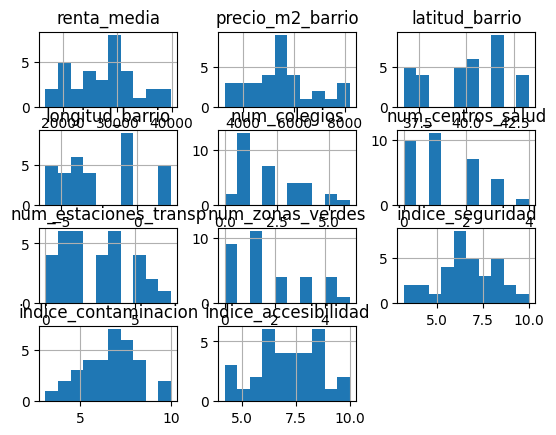

In [30]:
df_barrios.hist()

In [31]:
#Pintamos un boxplot con los valores en € para comprobar si hay outliers:
fig = px.box(
    df_barrios,
    y= ['renta_media', 'precio_m2_barrio']
)

fig.show()

In [32]:
#Vamos a ver la correlación del dataframe:
df_barrios[['precio_m2_barrio', 'renta_media', 'num_colegios', 'num_centros_salud', 'num_estaciones_transp', 'num_zonas_verdes', 'indice_seguridad', 'indice_contaminacion', 'indice_accesibilidad']].corr()

,precio_m2_barrio,renta_media,num_colegios,num_centros_salud,num_estaciones_transp,num_zonas_verdes,indice_seguridad,indice_contaminacion,indice_accesibilidad
precio_m2_barrio,1.000000,0.783812,-0.289691,-0.082112,-0.292473,-0.057309,0.094590,0.081710,-0.059428
renta_media,0.783812,1.000000,-0.327795,-0.109190,-0.346534,0.018714,0.193425,0.016222,-0.160364
num_colegios,-0.289691,-0.327795,1.000000,-0.040562,0.094032,-0.053782,0.019886,-0.012409,-0.275239
num_centros_salud,-0.082112,-0.109190,-0.040562,1.000000,-0.223365,0.045187,-0.045670,-0.009315,0.106244
num_estaciones_transp,-0.292473,-0.346534,0.094032,-0.223365,1.000000,0.146185,0.236593,-0.205659,-0.136087
num_zonas_verdes,-0.057309,0.018714,-0.053782,0.045187,0.146185,1.000000,0.019544,-0.274947,0.096094
indice_seguridad,0.094590,0.193425,0.019886,-0.045670,0.236593,0.019544,1.000000,0.138601,-0.169932
indice_contaminacion,0.081710,0.016222,-0.012409,-0.009315,-0.205659,-0.274947,0.138601,1.000000,-0.206046
indice_accesibilidad,-0.059428,-0.160364,-0.275239,0.106244,-0.136087,0.096094,-0.169932,-0.206046,1.000000


Vemos que realmente las columnas que están correladas son "precio_m2_barrio" y "renta_media", lo cual tiene sentido porque a mayor renta, mayor precio se paga por el metro cuadrado.

El resto de columnas vemos que, o tienen correlación negativa, o apenas tienen correlación. Investigaremos más adelante si se trata de datos erróneos o no.

In [33]:
#Vemos que sí hay una correlación positiva entre el precio_m2 y renta media, pintamos el gráfico para ver si tendencia.
fig = px.scatter(
    df_barrios,
    x= 'precio_m2_barrio',
    y= 'renta_media'
)

fig.show()

In [34]:
#Pintamos un boxplot con los números de servicios para comprobar si hay outliers:
fig = px.box(
    df_barrios,
    y= ['num_colegios', 'num_centros_salud', 'num_estaciones_transp', 'num_zonas_verdes']
)

fig.show()

In [35]:
#Pintamos un boxplot con los valores de los índices para comprobar si hay outliers:
fig = px.box(
    df_barrios,
    y= ['indice_seguridad', 'indice_contaminacion', 'indice_accesibilidad']
)

fig.show()

✅ **Conclusión sobre los outliers:**

No vemos outliers notables, en este caso lo más raro es la correlación negativa o muy baja entre variables que estudiaremos a continuación.

## 📈 1.3. Variables clave + Análisis

Con la limpieza de datos hecha, vamos a empezar a explorar algunos datos que tenemos en duda y a visualizarlos para poder entender mejor el dataframe y tomar decisiones. De esta manera, vamos a analizar los siguientes apartados.

###Renta media y precio m2 por barrio y ciudad

In [36]:
#Comparativa de renta media y precio m2 por ciudad.
df_barrios1 = df_barrios.groupby('ciudad').agg({'renta_media': 'mean', 'precio_m2_barrio': 'mean'}).sort_values('precio_m2_barrio', ascending=False).reset_index()
df_barrios1['renta_media'] = df_barrios1['renta_media'].round(2)
df_barrios1['precio_m2_barrio'] = df_barrios1['precio_m2_barrio'].round(2)
df_barrios1= df_barrios1.rename(columns={'precio_m2_barrio': 'precio_m2_media'})
df_barrios1

,ciudad,renta_media,precio_m2_media
0,Barcelona,32187.20,6228.20
1,Sevilla,29461.80,6215.00
2,Valencia,29699.40,6059.20
3,Madrid,28173.33,5149.00
4,Málaga,24139.25,5147.75
5,Bilbao,24046.25,4894.00
6,Zaragoza,22889.25,4878.75


In [37]:
fig= px.bar(
    df_barrios1,
    x = 'ciudad',
    y = ['renta_media', 'precio_m2_media'],
    barmode='group',
    title="Comparativa renta y precio m2 por ciudad",
    color_discrete_sequence=px.colors.qualitative.Set2
)

fig.update_layout(title_x=0.5)
fig.update_layout(
    xaxis_title='Ciudad',
    yaxis_title='Valor Medio'
)

fig.show()

In [38]:
fig = px.bar(
    df_barrios,
    y= "precio_m2_barrio",
    x = "barrio_distrito",
    color = "ciudad",
    title= "Tendencia del precio por m2 por barrio y ciudades ",
    custom_data = ['ciudad', 'precio_m2_barrio'],
    hover_data= {'ciudad':False}
)

fig.update_traces(
    hovertemplate = (
        "%{customdata[0]}<br>" +
        "Precio por m2 = %{customdata[1]:,.0f} €<br>" +
        "<extra></extra>"
    )
)

fig.update_layout(title_x=0.5)
fig.update_layout(xaxis_title= "Precio m2 cuadrado",
                  yaxis_title = "Barrio/Distrito")

fig.show()

Extraña ver estos datos por ciudad y barrio. Hay ciertos datos que no tienen mucho sentido como que:
- Sevilla y Valencia estén en el top 3 de ciudades con el precio m2 más caro, y Madrid se quede en el 4º puesto cuando es la ciudad más cara de España junto con Barcelona.
- Que algunos barrios tengan un precio_m2 bastante bajo cuando son de los barrios más caros de España, como puede ser el caso de "Chamberí", "Retiro", "Gràcia", etc.

De esta manera, podemos determinar que estos datos no son correctos, o por lo menos no está bien categorizados. Veremos en el dataframe de ciudades datos más veraces y que no coindicen con estos.

###Número y nivel de servicios de ciudades y barrios

In [39]:
#Comparativa de ciudades por número de servicios.
df_barrios2 = df_barrios.groupby('ciudad').agg({'num_colegios' : 'mean',
                                                'num_centros_salud' : 'mean',
                                                'num_estaciones_transp' : 'mean',
                                                'num_zonas_verdes' : 'mean'}).reset_index()
df_barrios2= df_barrios2.round(2)
df_barrios2

,ciudad,num_colegios,num_centros_salud,num_estaciones_transp,num_zonas_verdes
0,Barcelona,1.60,2.0,2.60,1.80
1,Bilbao,2.75,1.0,3.00,2.50
2,Madrid,1.83,1.0,4.17,1.83
3,Málaga,3.50,0.5,4.00,1.50
4,Sevilla,1.80,1.4,1.60,1.00
5,Valencia,1.80,1.6,2.20,1.80
6,Zaragoza,2.25,1.0,2.00,0.50


In [40]:
fig= px.bar(
    df_barrios2,
    x = 'ciudad',
    y = ['num_colegios', 'num_centros_salud', 'num_estaciones_transp', 'num_zonas_verdes'],
    barmode='group',
    title="Comparativa del número de servicios por ciudad",
    color_discrete_sequence=px.colors.qualitative.Set2
)

fig.update_layout(title_x=0.5)
fig.update_layout(
    xaxis_title='Ciudad',
    yaxis_title='Media por servicios'
)

fig.show()

In [41]:
fig= px.bar(
    df_barrios,
    x = 'barrio_distrito',
    y = ['num_colegios', 'num_centros_salud', 'num_estaciones_transp', 'num_zonas_verdes'],
    barmode='stack',
    title="Comparativa del número de servicios por ciudad",
    color_discrete_sequence=px.colors.qualitative.Set2
)

fig.update_layout(title_x=0.5)
fig.update_layout(
    xaxis_title='Barrio/Distrito',
    yaxis_title='Media por servicios'
)

fig.show()

In [42]:
#Visión general por ciudad:
fig= px.density_heatmap(
    df_barrios,
    x = 'ciudad',
    y = 'nivel_servicios',
    category_orders={'nivel_servicios': ['Alto', 'Medio', 'Bajo']},
    title="Mapa de calor del nivel de servicios por ciudad",
    text_auto=True,
    hover_data={'ciudad': True, 'nivel_servicios': True}
)

fig.update_layout(title_x=0.5)
fig.update_layout(
    xaxis_title='Ciudad',
    yaxis_title='Nivel de servicios'
)

fig.update_traces(
    hovertemplate="<b>%{x}</b><br>Nivel de servicios: %{y}<br>Frecuencia: %{z}<br><extra></extra>"
)

fig.show()

In [43]:
#Visión general por ciudad:
fig= px.density_heatmap(
    df_barrios,
    x = 'barrio_distrito',
    y = 'nivel_servicios',
    category_orders={'nivel_servicios': ['Alto', 'Medio', 'Bajo']},
    title="Mapa de calor del nivel de servicios por barrio",
    text_auto=True,
    hover_data={'barrio_distrito': True, 'nivel_servicios': True}
)

fig.update_layout(title_x=0.5)
fig.update_layout(
    xaxis_title='Barrio',
    yaxis_title='Nivel de servicios'
)

fig.update_traces(
    hovertemplate="<b>%{x}</b><br>Nivel de servicios: %{y}<br>Frecuencia: %{z}<br><extra></extra>"
)

fig.show()

De nuevo, vemos que estos datos son muy extraños, ya que podemos ver que los centros de las ciudades no tienen todos los servicios, y son muy bajos. Esto no tiene sentido ya que los centros de las ciudades son los que más servicios tienen disponibles.

De esta manera, podemos determinar que estos datos no son correctos, o por lo menos que no están bien categorizados.

###Índices por ciudad y barrio

In [44]:
#Comparativa de los índices por ciudad.
df_barrios3 = df_barrios.groupby('ciudad').agg({'indice_seguridad' : 'mean',
                                                'indice_contaminacion' : 'mean',
                                                'indice_accesibilidad' : 'mean'}).reset_index()
df_barrios3= df_barrios3.round(2)
df_barrios3

,ciudad,indice_seguridad,indice_contaminacion,indice_accesibilidad
0,Barcelona,7.92,6.58,6.80
1,Bilbao,6.80,6.40,8.00
2,Madrid,6.67,5.32,6.85
3,Málaga,6.70,6.48,7.05
4,Sevilla,6.54,7.06,7.38
5,Valencia,6.38,7.48,7.10
6,Zaragoza,5.00,7.65,6.95


In [45]:
fig = go.Figure()

for i, row in df_barrios3.iterrows():
    fig.add_trace(go.Scatterpolar(
        r=[row['indice_seguridad'], row['indice_contaminacion'], row['indice_accesibilidad']],
        theta=['Seguridad', 'Contaminación', 'Accesibilidad'],
        fill='toself',
        name=row['ciudad']
    ))

fig.update_layout(
    polar=dict(
        radialaxis=dict(
            visible=True,
            range=[0, 10]
        )
    ),
    showlegend=True,
    title='Indicadores medios por ciudad'
)

fig.show()

In [46]:
fig= px.bar(
    df_barrios,
    x = 'barrio_distrito',
    y = ['indice_seguridad', 'indice_contaminacion', 'indice_accesibilidad'],
    barmode='stack',
    title="Indicadores medios por barrio",
    color_discrete_sequence=px.colors.qualitative.Set2
)

fig.update_layout(title_x=0.5)
fig.update_layout(
    xaxis_title='Barrio/Distrito',
    yaxis_title='Índice de servicios'
)

fig.show()

Extraña ver estos índices por ciudad y barrio. Hay ciertos datos que no tienen mucho sentido como que:
- Barcelona sea la ciudad más segura, cuando es en la que más índice de criminalidad hay.
- Zaragoza sea la ciudad con más contaminación, cuando sin duda debería ser Madrid.
- Madrid sea una de las ciudades menos accesibles.

De esta manera, podemos determinar que estos datos no son correctos, o por lo menos no están bien categorizados.

##📝 1.4. Conclusiones sobre el df_barrios

Resumen:
- Los datos de latitud y longitud son incorrectos.
- Deducimos que los datos de "barrio_distrito" (y por consiguiente, "zona_geográfica") están mal categorizados ya que los datos no son representativos con respecto al resto de información que hay en el dataframe.
- Podría ser que los datos de número/nivel de servicios e índices sean incorrectos, pero la realidad es que sería más razonable que el error no se encuentre aquí.
- No hay forma de deducir qué barrios se corresponden en cada fila (ya que latitud y longitud son incorrectos), de tal manera que no podemos categorizar de nuevo la columna "barrio_distrito"

En este dataframe encontramos muchos errores que nos pueden revelar información no fiable. De tal manera que, para la deteccioón de oportunidades, no deberíamos tener en cuenta la información de este dataframe tal cuál está, y continuar con otros dataframes que contengan datos que sí nos puedan aportar insights reales.

#📎 2. EDA CIUDADES

## 🔍 2.1. Carga y comprensión inicial del dataset

Vamos a visualizar el df de Ciudades. Para ello, vamos a:
- Ver una muestra con el .head() con el objetivo de ver las columnas del dataframe y los valores que nos podemos encontrar dentro de él.
- Ver la cantidad de filas y columnas con el .shape.
- Ver un resumen con la información de las columnas, para ver el tipo de datos y si hay nulos en cada una de ellas, con el .info().
- Ver un .describe() para ver las estadísticas básicas de los datos.

In [47]:
df_ciudades

,ciudad,comunidad_autonoma,poblacion,superficie_km2,precio_m2_medio,latitud_centro,longitud_centro
0,Madrid,Madrid,3300000,604.3,5000,40.4168,-3.7038
1,Barcelona,Cataluña,1600000,101.9,4500,41.3851,2.1734
2,Valencia,Comunidad Valenciana,800000,134.6,3000,39.4699,-0.3763
3,Sevilla,Andalucía,700000,140.0,3200,37.3891,-5.9845
4,Bilbao,País Vasco,345000,41.6,4000,43.2630,-2.9350
5,Málaga,Andalucía,578000,398.0,3500,36.7213,-4.4214
6,Zaragoza,Aragón,675000,973.0,2800,41.6488,-0.8891


In [48]:
df_ciudades.shape

(7, 7)

In [49]:
df_ciudades.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ciudad              7 non-null      object 
 1   comunidad_autonoma  7 non-null      object 
 2   poblacion           7 non-null      int64  
 3   superficie_km2      7 non-null      float64
 4   precio_m2_medio     7 non-null      int64  
 5   latitud_centro      7 non-null      float64
 6   longitud_centro     7 non-null      float64
dtypes: float64(3), int64(2), object(2)
memory usage: 524.0+ bytes


In [50]:
df_ciudades.describe().round(2)

,poblacion,superficie_km2,precio_m2_medio,latitud_centro,longitud_centro
count,7.00,7.00,7.00,7.00,7.00
mean,1142571.43,341.91,3714.29,40.04,-2.31
std,1028789.56,342.01,817.37,2.36,2.77
min,345000.00,41.60,2800.00,36.72,-5.98
25%,626500.00,118.25,3100.00,38.43,-4.06
50%,700000.00,140.00,3500.00,40.42,-2.94
75%,1200000.00,501.15,4250.00,41.52,-0.63
max,3300000.00,973.00,5000.00,43.26,2.17


##📊 2.2. Limpieza de los datos

###Estandarizar datos

A simple vista, y junto con las descripciones del código anterior, podemos ver que el df está muy limpio. Sin embargo, vamos a hacer una rápida comprobación.

Los datos de coordenadas en este caso sí son correctos y se corresponden con las ciudades.

In [51]:
#Imprimimos un mapa para ver si las coordenadas se corresponden con las ciudades del dataframe.
mapa = folium.Map(location=[40.4168, -3.7038], zoom_start=6)

for i, row in df_ciudades.iterrows():
    folium.Marker(
        location=[row['latitud_centro'], row['longitud_centro']],
        popup=f"{row['ciudad']}",
        icon=folium.Icon(color="blue")
    ).add_to(mapa)

mapa

In [52]:
def limpiar_inconsistencias(df_ciudades):
  df_ciudades.columns=(
        df_ciudades.columns
        .str.strip()
        .str.lower()
        .str.replace(' ', '_')
        .str.replace(r'[^\w_]', '', regex=True)
    )
  for col in df_ciudades.select_dtypes(include='object').columns:
        df_ciudades[col] = (
            df_ciudades[col]
            .where(df_ciudades[col].isna(), df_ciudades[col].str.strip().str.replace(r'\s+', ' ', regex=True))
        )

  return df_ciudades

In [53]:
df_ciudades = limpiar_inconsistencias(df_ciudades)

###Tratamiento de valores nulos

In [54]:
df_ciudades.isnull().sum()

,0
ciudad,0
comunidad_autonoma,0
poblacion,0
superficie_km2,0
precio_m2_medio,0
latitud_centro,0
longitud_centro,0


###Tratamiento de duplicados

Vamos a comprobar si hay algún valor duplicado en la columna "ciudad", que es la que tiene los valores únicos en el dataframe.

In [55]:
df_ciudades['ciudad'].duplicated().sum()

np.int64(0)

###Tratamiento de outliers

In [56]:
df_ciudades.describe().round(2)

,poblacion,superficie_km2,precio_m2_medio,latitud_centro,longitud_centro
count,7.00,7.00,7.00,7.00,7.00
mean,1142571.43,341.91,3714.29,40.04,-2.31
std,1028789.56,342.01,817.37,2.36,2.77
min,345000.00,41.60,2800.00,36.72,-5.98
25%,626500.00,118.25,3100.00,38.43,-4.06
50%,700000.00,140.00,3500.00,40.42,-2.94
75%,1200000.00,501.15,4250.00,41.52,-0.63
max,3300000.00,973.00,5000.00,43.26,2.17


array([[<Axes: title={'center': 'poblacion'}>,
        <Axes: title={'center': 'superficie_km2'}>],
       [<Axes: title={'center': 'precio_m2_medio'}>,
        <Axes: title={'center': 'latitud_centro'}>],
       [<Axes: title={'center': 'longitud_centro'}>, <Axes: >]],
      dtype=object)

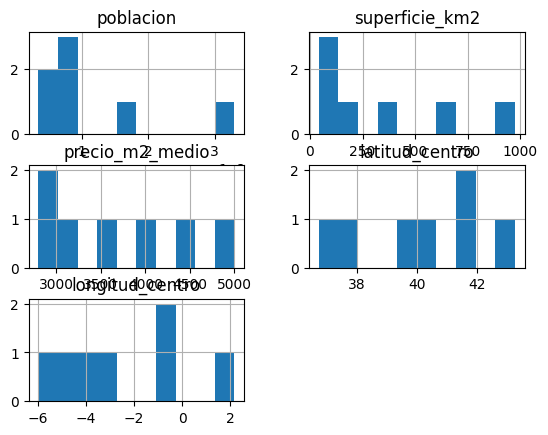

In [57]:
df_ciudades.hist()

In [58]:
#Vamos a ver la correlación del dataframe:
df_ciudades[['poblacion', 'superficie_km2','precio_m2_medio', 'latitud_centro', 'longitud_centro']].corr()

,poblacion,superficie_km2,precio_m2_medio,latitud_centro,longitud_centro
poblacion,1.000000,0.250793,0.778160,0.092676,0.060384
superficie_km2,0.250793,1.000000,-0.163433,0.060142,-0.023678
precio_m2_medio,0.778160,-0.163433,1.000000,0.300626,0.089249
latitud_centro,0.092676,0.060142,0.300626,1.000000,0.546504
longitud_centro,0.060384,-0.023678,0.089249,0.546504,1.000000


Vemos que el precio_m2_medio sí tiene correlación con la población. Es decir, a más población mayor es el precio del m2.

Sin embargo, observamos que la superficie_km2 tiene una correlación muy baja con respecto a la población, lo que quiere decir que si la superficie es mayor, no tiene por qué haber mayor población.

In [59]:
#Pintamos un boxplot con los valores de la problación mundial para comprobar si hay outliers:
fig = px.box(
    df_ciudades,
    y= ['poblacion']
)

fig.show()

In [60]:
#Pintamos un boxplot con los valores de superficie y precio m2 para comprobar si hay outliers:
fig = px.box(
    df_ciudades,
    y= ['precio_m2_medio', 'superficie_km2']
)

fig.show()

✅ **Conclusión sobre los outliers:**

Encontramos un outlier en la población de Madrid. No lo podemos considerar un error ya que, a pesar de tener mucha diferencia por el resto de ciudades, es un dato que tiene base real.

## 📈 2.3. Variables clave + Análisis

Con la limpieza de datos hecha, vamos a empezar a explorar algunos datos que tenemos en duda y a visualizarlos para poder entender mejor el dataframe y tomar decisiones. De esta manera, vamos a analizar los siguientes apartados.

###Población por ciudad y comunidad autónoma.

In [61]:
df_ciudades1 = df_ciudades.groupby(['comunidad_autonoma', 'ciudad']).agg({'poblacion':'sum'}).sort_values("poblacion", ascending = False).reset_index()
df_ciudades1

,comunidad_autonoma,ciudad,poblacion
0,Madrid,Madrid,3300000
1,Cataluña,Barcelona,1600000
2,Comunidad Valenciana,Valencia,800000
3,Andalucía,Sevilla,700000
4,Aragón,Zaragoza,675000
5,Andalucía,Málaga,578000
6,País Vasco,Bilbao,345000


In [62]:
fig = px.bar(
    df_ciudades1,
    x = 'comunidad_autonoma',
    y = 'poblacion',
    barmode='group',
    title = "Población por Comunidad autónoma y Ciudad",
    text='ciudad',
    hover_data = {'comunidad_autonoma':True, 'poblacion': True, 'ciudad':False},
    custom_data=['comunidad_autonoma', 'poblacion']

)

fig.update_traces(
    hovertemplate=(
        "Comunidad Autónoma: %{customdata[0]}<br>" +
        "Población: %{customdata[1]:,}<br>"
    )
)

fig.update_layout(title_x=0.5)
fig.update_layout(
    xaxis_title='Comunidad autónoma',
    yaxis_title='Población'
)

fig.show()

###Precio m2 por ciudad

In [63]:
df_ciudades2 = df_ciudades.groupby(['comunidad_autonoma', 'ciudad']).agg({'precio_m2_medio':'mean'}).sort_values("precio_m2_medio", ascending = False).reset_index()
df_ciudades2

,comunidad_autonoma,ciudad,precio_m2_medio
0,Madrid,Madrid,5000.0
1,Cataluña,Barcelona,4500.0
2,País Vasco,Bilbao,4000.0
3,Andalucía,Málaga,3500.0
4,Andalucía,Sevilla,3200.0
5,Comunidad Valenciana,Valencia,3000.0
6,Aragón,Zaragoza,2800.0


In [64]:
fig = px.bar(
    df_ciudades2,
    y= "precio_m2_medio",
    x = 'comunidad_autonoma',
    barmode='group',
    title= "Precio m2 por ciudades",
    text='ciudad',
    custom_data = ['comunidad_autonoma', 'precio_m2_medio'],
    hover_data= {'ciudad':False}
)

fig.update_traces(
    hovertemplate = (
        "%{customdata[0]}<br>" +
        "Precio por m2 = %{customdata[1]:,.0f} €<br>" +
        "<extra></extra>"
    )
)

fig.update_layout(title_x=0.5)
fig.update_layout(xaxis_title= "Precio m2 cuadrado",
                  yaxis_title = "Ciudad")

fig.show()

###Mapa comparativo de todos los datos del df_ciudades.

In [65]:
fig = px.scatter_map(df_ciudades,
                     lat= 'latitud_centro',
                     lon='longitud_centro',
                     size='poblacion',
                     color='superficie_km2',
                     zoom=4.5,
                     color_continuous_scale=px.colors.cyclical.IceFire,
                     title = 'Mapa de comparativa por ciudades',
                     hover_data = {'ciudad': True, 'comunidad_autonoma':True, 'precio_m2_medio': True, 'poblacion' : True, 'superficie_km2':True, 'latitud_centro':False, 'longitud_centro': False})

fig.update_traces(
    hovertemplate=(
        "<b>%{customdata[0]}</b><br>" +
        "<b>%{customdata[1]}</b><br>" +
        "Precio m² medio: %{customdata[2]:,.0f} €<br>" +
        "Población: %{customdata[3]:,}<br>" +
        "Superficie: %{customdata[4]:,.1f} km²<br>"
    )
)

fig.update_layout(title_x = 0.5)

fig.show()

##📝 2.4. Conclusiones sobre el df_ciudades

Resumen:
- Madrid es la ciudad con más superficie y más población.
- Hay ciudades como Zaragoza que tienen mucha superficie pero muy poca población, de ahí que los datos no hayan salido tan correlados. Esto tiene sentido porque las personas se suelen aglomerar en las grandes ciudades como Madrid y Barcelona.
- Hay algunas ciudades como Bilbao, que a pesar de tener la menor población, tiene el precio del m2 alto.

Podemos concluir que los datos de este dataframe sí son fiables, y que por lo tanto podremos obtener insights y oportunidades de negocio a partir de ellos.


#📎 3. EDA INMOBILIARIO

## 🔍 3.1. Carga y comprensión inicial del dataset

Vamos a visualizar el df de Inmobiliario. Para ello, vamos a:
- Ver una muestra con el .head() con el objetivo de ver las columnas del dataframe y los valores que nos podemos encontrar dentro de él.
- Ver la cantidad de filas y columnas con el .shape.
- Ver un resumen con la información de las columnas, para ver el tipo de datos y si hay nulos en cada una de ellas, con el .info().
- Ver un .describe() para ver las estadísticas básicas de los datos.

In [66]:
df_inmobiliario.head()

,id_propiedad,ciudad,barrio,tipo_operacion,tipo_inmueble,precio,superficie_m2,habitaciones,baños,estado,año_construccion,planta,ascensor,terraza,piscina,garaje,trastero,distancia_centro_km,fecha_publicacion
0,1,Madrid,Arganzuela,Venta,Estudio,NaN,57.800000,3.0,1.0,Buen estado,2000,2,True,True,False,False,True,4.10,2024-11-04
1,2,Madrid,Arganzuela,Alquiler,Piso,NaN,NaN,3.0,1.0,Buen estado,1996,Bajo,True,True,False,False,True,5.26,2024-10-16
2,3,Madrid,Salamanca,Venta,Piso,821455.0,153.978185,2.0,1.0,Buen estado,1996,3,False,True,False,False,False,5.13,2025-03-24
3,4,Madrid,Arganzuela,Venta,Piso,337577.0,74.000000,4.0,2.0,Buen estado,1945,Bajo,True,True,False,False,False,5.52,2024-11-18
4,5,Madrid,Arganzuela,Venta,Piso,394652.0,82.000000,3.0,1.0,Buen estado,1981,5,True,False,NaN,False,True,5.97,2024-11-04


In [67]:
df_inmobiliario.tail()

,id_propiedad,ciudad,barrio,tipo_operacion,tipo_inmueble,precio,superficie_m2,habitaciones,baños,estado,año_construccion,planta,ascensor,terraza,piscina,garaje,trastero,distancia_centro_km,fecha_publicacion
6995,6996,Zaragoza,La Romareda,Venta,Ático,150411.0,70.500000,5.0,1.0,Buen estado,1976,2,False,False,False,False,False,4.08,2025-01-15
6996,6997,Zaragoza,Centro,Venta,Piso,147376.0,64.800000,7.0,1.0,A reformar,1999,4,True,False,NaN,False,False,5.01,2024-11-11
6997,6998,Zaragoza,San José,Venta,Ático,461868.0,148.102288,3.0,NaN,Buen estado,1956,6,False,True,False,True,False,5.59,2024-11-02
6998,6999,Zaragoza,Delicias,Venta,Piso,207797.0,66.300000,1.0,1.0,Buen estado,1987,1,True,True,False,False,True,4.03,2024-10-10
6999,7000,Zaragoza,Centro,Venta,Estudio,236017.0,81.100000,1.0,1.0,Buen estado,1985,9,True,False,False,False,False,3.11,2024-12-23


In [68]:
df_inmobiliario.sample(5)

,id_propiedad,ciudad,barrio,tipo_operacion,tipo_inmueble,precio,superficie_m2,habitaciones,baños,estado,año_construccion,planta,ascensor,terraza,piscina,garaje,trastero,distancia_centro_km,fecha_publicacion
1952,1953,Barcelona,Ciutat Vella,Alquiler,Estudio,NaN,NaN,1.0,1.0,A reformar,2011,3,False,True,False,False,True,5.61,2025-03-02
1329,1330,Madrid,Centro,Alquiler,Estudio,347315.0,63.9,3.0,1.0,Reformado,2003,5,False,False,False,True,False,3.59,2025-01-05
6619,6620,Zaragoza,La Romareda,Venta,Piso,191291.0,69.0,2.0,1.0,Buen estado,1979,Bajo,True,True,False,True,False,5.01,2025-03-31
3200,3201,Valencia,Ensanche,Venta,Piso,319178.0,101.0,1.0,1.0,Reformado,2019,3,True,False,False,False,True,5.34,2025-01-03
1508,1509,Barcelona,Gràcia,Venta,Piso,278673.0,57.8,3.0,1.0,Buen estado,1973,7,False,True,False,False,True,7.39,2025-03-19


In [69]:
df_inmobiliario.shape

(7000, 19)

In [70]:
df_inmobiliario.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id_propiedad         7000 non-null   int64  
 1   ciudad               7000 non-null   object 
 2   barrio               7000 non-null   object 
 3   tipo_operacion       7000 non-null   object 
 4   tipo_inmueble        7000 non-null   object 
 5   precio               6312 non-null   float64
 6   superficie_m2        6653 non-null   float64
 7   habitaciones         6649 non-null   float64
 8   baños                6656 non-null   float64
 9   estado               7000 non-null   object 
 10  año_construccion     7000 non-null   int64  
 11  planta               7000 non-null   object 
 12  ascensor             6633 non-null   object 
 13  terraza              6654 non-null   object 
 14  piscina              6651 non-null   object 
 15  garaje               6656 non-null   o

In [71]:
df_inmobiliario.describe().round(2)

,id_propiedad,precio,superficie_m2,habitaciones,baños,año_construccion,distancia_centro_km
count,7000.00,6312.00,6653.00,6649.00,6656.00,7000.00,6641.00
mean,3500.50,313843.86,81.09,2.55,1.39,1989.63,5.02
std,2020.87,115579.24,21.36,1.45,0.72,18.85,1.50
min,1.00,59138.00,30.00,1.00,1.00,1940.00,0.50
25%,1750.75,231342.75,67.20,1.00,1.00,1976.00,4.00
50%,3500.50,299201.00,80.60,2.00,1.00,1988.00,5.00
75%,5250.25,381054.25,94.10,3.00,2.00,2002.00,6.03
max,7000.00,1282678.00,235.26,9.00,6.00,2023.00,9.87


##📊 3.2. Limpieza de los datos

###Estandarizar datos

Podemos ver que:
- Los pisos están en tipo 'object'. No obstante, teniendo en cuenta que es una categorización, y que hay valores que son "Bajo" o "Ático", podemos dejarlo como está.
- Convertimos a booleano los valores con True/False.
- Para facilitar el trabajo, sí pasaríamos las columnas de "fecha_publicacion" y "año construccion" a formato fecha.
- Vamos a cambiar de nombre la columna "barrio" a "barrio_distrito" para que coincida con el df_barrios.
- Redondeamos la columna "precio" y "superficie_m2" a dos decimales.

In [72]:
cols = ['ascensor', 'terraza', 'piscina', 'garaje', 'trastero']
df_inmobiliario[cols] = df_inmobiliario[cols].astype('bool')

In [73]:
df_inmobiliario ['fecha_publicacion'] = pd.to_datetime(df_inmobiliario ['fecha_publicacion'], format= '%Y-%m-%d')
df_inmobiliario ['año_construccion'] = pd.to_datetime(df_inmobiliario ['año_construccion'], format= '%Y')
df_inmobiliario.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   id_propiedad         7000 non-null   int64         
 1   ciudad               7000 non-null   object        
 2   barrio               7000 non-null   object        
 3   tipo_operacion       7000 non-null   object        
 4   tipo_inmueble        7000 non-null   object        
 5   precio               6312 non-null   float64       
 6   superficie_m2        6653 non-null   float64       
 7   habitaciones         6649 non-null   float64       
 8   baños                6656 non-null   float64       
 9   estado               7000 non-null   object        
 10  año_construccion     7000 non-null   datetime64[ns]
 11  planta               7000 non-null   object        
 12  ascensor             7000 non-null   bool          
 13  terraza              7000 non-nul

In [74]:
#Renombramos las columnas con el nombre correcto
df_inmobiliario = df_inmobiliario.rename(columns={'barrio': 'barrio_distrito'})
df_inmobiliario.head()

,id_propiedad,ciudad,barrio_distrito,tipo_operacion,tipo_inmueble,precio,superficie_m2,habitaciones,baños,estado,año_construccion,planta,ascensor,terraza,piscina,garaje,trastero,distancia_centro_km,fecha_publicacion
0,1,Madrid,Arganzuela,Venta,Estudio,NaN,57.800000,3.0,1.0,Buen estado,2000-01-01,2,True,True,False,False,True,4.10,2024-11-04
1,2,Madrid,Arganzuela,Alquiler,Piso,NaN,NaN,3.0,1.0,Buen estado,1996-01-01,Bajo,True,True,False,False,True,5.26,2024-10-16
2,3,Madrid,Salamanca,Venta,Piso,821455.0,153.978185,2.0,1.0,Buen estado,1996-01-01,3,False,True,False,False,False,5.13,2025-03-24
3,4,Madrid,Arganzuela,Venta,Piso,337577.0,74.000000,4.0,2.0,Buen estado,1945-01-01,Bajo,True,True,False,False,False,5.52,2024-11-18
4,5,Madrid,Arganzuela,Venta,Piso,394652.0,82.000000,3.0,1.0,Buen estado,1981-01-01,5,True,False,True,False,True,5.97,2024-11-04


In [75]:
df_inmobiliario['precio'] = df_inmobiliario['precio'].round(2)
df_inmobiliario['superficie_m2'] = df_inmobiliario['superficie_m2'].round(2)

In [76]:
def limpiar_inconsistencias(df_inmobiliario):
    df_inmobiliario.columns = (
        df_inmobiliario.columns
        .str.strip()
        .str.lower()
        .str.replace(' ', '_')
        .str.replace(r'[^\w_]', '', regex=True)
    )
    for col in df_inmobiliario.select_dtypes(include='object').columns:
        df_inmobiliario[col] = (
            df_inmobiliario[col]
            .astype(str)
            .str.strip()
            .str.replace(r'\s+', ' ', regex=True)
        )

    return df_inmobiliario

In [77]:
df_inmobiliario = limpiar_inconsistencias(df_inmobiliario)

In [78]:
df_inmobiliario['ciudad'].unique()

array(['Madrid', 'Barcelona', 'Valencia', 'Sevilla', 'Bilbao', 'Málaga',
       'Zaragoza'], dtype=object)

In [79]:
df_inmobiliario['barrio_distrito'].unique()

array(['Arganzuela', 'Salamanca', 'Retiro', 'Centro', 'Chamberí',
       'Tetuán', 'Eixample', 'Gràcia', 'Sants-Montjuïc',
       'Sarrià-Sant Gervasi', 'Ciutat Vella', 'Campanar', 'Ensanche',
       'El Carmen', 'Ruzafa', 'Benimaclet', 'Triana', 'Macarena',
       'Nervión', 'Los Remedios', 'Santa Cruz', 'Deusto', 'Casco Viejo',
       'Indautxu', 'Abando', 'El Palo', 'Pedregalejo', 'La Malagueta',
       'San José', 'Delicias', 'La Romareda'], dtype=object)

In [80]:
df_inmobiliario['tipo_operacion'].unique()

array(['Venta', 'Alquiler'], dtype=object)

In [81]:
df_inmobiliario['tipo_inmueble'].unique()

array(['Estudio', 'Piso', 'Ático', 'Dúplex', 'Chalet'], dtype=object)

In [82]:
df_inmobiliario['estado'].unique()

array(['Buen estado', 'Reformado', 'Obra nueva', 'A reformar'],
      dtype=object)

In [83]:
df_inmobiliario['planta'].unique()

array(['2', 'Bajo', '3', '5', '4', '1', '9', '6', '7', '8', 'Ático'],
      dtype=object)

###Tratamiento de los valores nulos

En este caso sí vemos varios valores nulos, vamos a representarlos en un resumen por columna:

In [84]:
df_inmobiliario.isnull().sum()

,0
id_propiedad,0
ciudad,0
barrio_distrito,0
tipo_operacion,0
tipo_inmueble,0
precio,688
superficie_m2,347
habitaciones,351
baños,344
estado,0


Parece que no son muchos datos con respecto a la totalidad del dataframe, pero vamos a confirmar qué porcentaje de nulos representa cada columna para tomar decisiones al respecto.

In [85]:
nulos_precio = (df_inmobiliario['precio'].isnull().sum())/(df_inmobiliario.shape[0])*100
print(f"Hay {nulos_precio.round(2)}% de nulos en la columna precio")

nulos_superficie_m2 = (df_inmobiliario['superficie_m2'].isnull().sum())/(df_inmobiliario.shape[0])*100
print(f"Hay {nulos_superficie_m2.round(2)}% de nulos en la columna superficie_m2")

nulos_habitaciones = (df_inmobiliario['habitaciones'].isnull().sum())/(df_inmobiliario.shape[0])*100
print(f"Hay {nulos_habitaciones.round(2)}% de nulos en la columna habitaciones")

nulos_baños = (df_inmobiliario['baños'].isnull().sum())/(df_inmobiliario.shape[0])*100
print(f"Hay {nulos_baños.round(2)}% de nulos en la columna baños")

nulos_ascensor = (df_inmobiliario['ascensor'].isnull().sum())/(df_inmobiliario.shape[0])*100
print(f"Hay {nulos_ascensor.round(2)}% de nulos en la columna ascensor")

nulos_terraza = (df_inmobiliario['terraza'].isnull().sum())/(df_inmobiliario.shape[0])*100
print(f"Hay {nulos_terraza.round(2)}% de nulos en la columna terraza")

nulos_piscina = (df_inmobiliario['piscina'].isnull().sum())/(df_inmobiliario.shape[0])*100
print(f"Hay {nulos_piscina.round(2)}% de nulos en la columna piscina")

nulos_garaje = (df_inmobiliario['garaje'].isnull().sum())/(df_inmobiliario.shape[0])*100
print(f"Hay {nulos_garaje.round(2)}% de nulos en la columna garaje")

nulos_trastero = (df_inmobiliario['trastero'].isnull().sum())/(df_inmobiliario.shape[0])*100
print(f"Hay {nulos_trastero.round(2)}% de nulos en la columna trastero")

nulos_distancia_centro_km = (df_inmobiliario['distancia_centro_km'].isnull().sum())/(df_inmobiliario.shape[0])*100
print(f"Hay {nulos_distancia_centro_km.round(2)}% de nulos en la columna distancia_centro_km")

nulos_fecha_publicacion = (df_inmobiliario['fecha_publicacion'].isnull().sum())/(df_inmobiliario.shape[0])*100
print(f"Hay {nulos_fecha_publicacion.round(2)}% de nulos en la columna fecha_publicacion")

Hay 9.83% de nulos en la columna precio
Hay 4.96% de nulos en la columna superficie_m2
Hay 5.01% de nulos en la columna habitaciones
Hay 4.91% de nulos en la columna baños
Hay 0.0% de nulos en la columna ascensor
Hay 0.0% de nulos en la columna terraza
Hay 0.0% de nulos en la columna piscina
Hay 0.0% de nulos en la columna garaje
Hay 0.0% de nulos en la columna trastero
Hay 5.13% de nulos en la columna distancia_centro_km
Hay 4.6% de nulos en la columna fecha_publicacion


Al ser los nulos menores a un 10% en todos los casos, vamos a tomar las siguientes acciones:
- **Superficie y Precio:** exploraremos los datos de los tipos de inmuebles por si hubiera errores antes de determinar qué acciones tomar con estos nulos.
- **Habitaciones y Baños:** exploraremos más estas columnas por si hubiera errores antes de determinar qué acciones tomar con estos nulos.
- **Ascensor, Terraza, Piscina, Garaje y Trastero:** los dejaremos como nulos porque no hay forma de obtener un dato realista de estas columnas, y al ser un porcentaje menor al 5%, afecta mínimamente al análisis.
- **Distancia centro km:** vamos explorar si las distancias son las mismas por cada barrio, o si es la localización exacta del piso. En caso de ser la primera, pondríamos la distancia correspondiente; en caso de ser la segunda, lo dejaremos como nulo porque no hay manera de obtener este dato.
- **Fecha de publicación:** lo dejaremos como nulo porque no hay manera de obtener este dato.

In [86]:
#DISTANCIA CENTRO KM
#Vamos a probar con un barrio aleatorio, en este caso Salamanca
df_filtrado = df_inmobiliario[df_inmobiliario['barrio_distrito'] == 'Salamanca']
df_filtrado.head()

,id_propiedad,ciudad,barrio_distrito,tipo_operacion,tipo_inmueble,precio,superficie_m2,habitaciones,baños,estado,año_construccion,planta,ascensor,terraza,piscina,garaje,trastero,distancia_centro_km,fecha_publicacion
2,3,Madrid,Salamanca,Venta,Piso,821455.0,153.98,2.0,1.0,Buen estado,1996-01-01,3,False,True,False,False,False,5.13,2025-03-24
5,6,Madrid,Salamanca,Venta,Piso,270381.0,55.50,2.0,3.0,Buen estado,1994-01-01,4,True,False,True,True,True,6.83,2024-10-20
13,14,Madrid,Salamanca,Alquiler,Piso,359713.0,79.60,4.0,1.0,Buen estado,1972-01-01,9,False,False,False,False,False,4.83,2024-12-28
17,18,Madrid,Salamanca,Alquiler,Ático,299734.0,68.90,1.0,2.0,Buen estado,1988-01-01,2,True,True,False,False,False,7.29,2025-04-01
25,26,Madrid,Salamanca,Venta,Piso,507831.0,97.20,2.0,3.0,Buen estado,1971-01-01,7,False,False,False,False,True,4.97,2024-10-26


Confirmamos que la distancia es por piso, y no por barrio, así que dejamos los nulos.

###Tratamiento de duplicados

Vamos a comprobar si hay algún valor duplicado en la columna "id_propiedad", que es la que tiene los valores únicos en el dataframe.

In [87]:
df_inmobiliario['id_propiedad'].duplicated().sum()

np.int64(0)

Por otro lado, vamos a categorizar los barrios que están como "centro" con el subnombre que le añadimos al df_barrios

In [88]:
df_inmobiliario.loc[(df_inmobiliario['ciudad'] == "Madrid") & (df_inmobiliario['barrio_distrito'] == "Centro"), "barrio_distrito"] = "Madrid-Centro"
df_inmobiliario.loc[(df_inmobiliario['ciudad'] == "Zaragoza") & (df_inmobiliario['barrio_distrito'] == "Centro"), "barrio_distrito"] = "Zaragoza_Centro"
df_inmobiliario.loc[(df_inmobiliario['ciudad'] == "Málaga") & (df_inmobiliario['barrio_distrito'] == "Centro"), "barrio_distrito"] = "Málaga-Centro"

###Corrección de los tipos de inmuebles

Podemos ver de un vistazo que es posible que haya datos inconsistentes, por lo que vamos a hacer una exploración de los datos y a corregirlos si fuera necesario.

Primero, vamos a hacer una agrupación por el tipo de inmueble, para ver su representatividad:

In [89]:
#MEDIA
df_inmobiliario.groupby('tipo_inmueble').agg({'precio': 'mean', 'superficie_m2':'mean', 'habitaciones': 'mean', 'baños': 'mean'}).reset_index().round(2)

,tipo_inmueble,precio,superficie_m2,habitaciones,baños
0,Chalet,316941.28,82.40,2.67,1.40
1,Dúplex,310201.58,79.90,2.51,1.38
2,Estudio,309539.16,80.43,2.54,1.45
3,Piso,314665.61,81.23,2.56,1.37
4,Ático,317530.67,81.70,2.50,1.37


In [90]:
#MAX
df_inmobiliario.groupby('tipo_inmueble').agg({'precio': 'max', 'superficie_m2':'max', 'habitaciones': 'max', 'baños': 'max'}).reset_index().round(2)

,tipo_inmueble,precio,superficie_m2,habitaciones,baños
0,Chalet,1087781.0,208.01,9.0,5.0
1,Dúplex,998925.0,206.71,8.0,5.0
2,Estudio,875677.0,188.65,9.0,6.0
3,Piso,1282678.0,235.26,9.0,6.0
4,Ático,806753.0,188.60,8.0,5.0


In [91]:
#MIN
df_inmobiliario.groupby('tipo_inmueble').agg({'precio': 'min', 'superficie_m2':'min', 'habitaciones': 'min', 'baños': 'min'}).reset_index().round(2)

,tipo_inmueble,precio,superficie_m2,habitaciones,baños
0,Chalet,83921.0,30.0,1.0,1.0
1,Dúplex,73341.0,30.0,1.0,1.0
2,Estudio,59138.0,30.0,1.0,1.0
3,Piso,65125.0,30.0,1.0,1.0
4,Ático,61013.0,30.0,1.0,1.0


Con estas agrupaciones vemos claramente que los datos de la columna "tipo_inmueble" no están bien categorizados, ya que tienen resultados prácticamente iguales. Esto no tiene sentido, porque un chalet no mide solo 30m2, igual que un Estudio no tiene 9 habitaciones y 6 baños.

De esta manera, vamos a seguir los siguientes pasos:
- Detectar inconsistencias en torno a los datos de superficie, habitaciones y baños.
- Categorizar de nuevo la columna "tipo_inmueble" en los datos consistentes.
- Determinar qué hacemos con los datos inconsistentes.

In [92]:
#DETECTAR INCONSISTENCIAS

#Vamos a determinar las filas que tienen inconsistencias y las guardaremos en un df.
def validar_inmueble(row):
    try:
        sup = float(row['superficie_m2'])
        hab = float(row['habitaciones'])
        baños = float(row['baños'])
    except:
        return True  # Si falta algún dato o no es convertible, consideramos inconsistente

    # Regla 1: estudios con una habitación o más:
    if sup < 40 and hab >= 1:
        return True

    # Regla 2: más baños que habitaciones:
    if baños > hab + 1:
        return True

    # Regla 3: habitaciones desproporcionadas respecto a superficie:
    if hab > sup / 30:
        return True

    return False

df_inmobiliario['inconsistente'] = df_inmobiliario.apply(validar_inmueble, axis=1)
df_inconsistentes = df_inmobiliario[df_inmobiliario['inconsistente'] == True] #datos inconsistentes
df_consistente = df_inmobiliario[df_inmobiliario['inconsistente'] == False] #datos consistentes

print(f"Filas con datos inconsistentes: {len(df_inconsistentes)}, que suponen un {(len(df_inconsistentes)*100)/ df_inmobiliario.shape[0]}%")

Filas con datos inconsistentes: 2866, que suponen un 40.94285714285714%


In [93]:
#CATEGORIZAR LA COLUMNA "TIPO_INMUBLE" CORRECTAMENTE
def reclasificar_tipo_inmueble(row):
    sup = row['superficie_m2']
    hab = row['habitaciones']
    planta = str(row['planta'])
    terraza = row['terraza']

    # Ático siempre que planta sea 'Ático'
    if planta == 'Ático':
        return 'Ático'

    # Estudio
    if sup <= 40 and hab == 0:
        return 'Estudio'

    # Piso estándar
    if 40 < sup < 150 and 1 <= hab <= 4:
        return 'Piso'

    # Chalet (grande, planta baja, varias habitaciones)
    if planta == '1' and sup >= 150:
        return 'Chalet'

    # Dúplex si es grande pero no bajo ni ático
    if 80 <= sup <= 110 and 1 < hab < 3 and planta not in ['Bajo, Ático']:
        return 'Dúplex'

    return 'Sin clasificar'

df_consistente['tipo_inmueble_corregido'] = df_consistente.apply(reclasificar_tipo_inmueble, axis=1)

/tmp/ipython-input-3106046411.py:30: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [94]:
df_consistente['tipo_inmueble_corregido'].value_counts()

,count
tipo_inmueble_corregido,
Piso,3110
Sin clasificar,627
Ático,394
Chalet,3


In [95]:
df_consistente.groupby('tipo_inmueble_corregido').agg({'precio': 'mean', 'superficie_m2':'mean', 'habitaciones': 'mean', 'baños': 'mean'}).reset_index().round(2)

,tipo_inmueble_corregido,precio,superficie_m2,habitaciones,baños
0,Chalet,855063.33,208.82,1.33,1.67
1,Piso,331405.52,85.78,1.65,1.26
2,Sin clasificar,356032.06,92.33,2.62,1.41
3,Ático,334092.62,85.50,1.72,1.25


Vemos que esto no nos devuelve datos de habitaciones y baños muy fiables, de tal manera que podemos concluir que esta línea de análisis no ha tenido éxito.

**Partiendo de la hipótesis de que los datos de "habitaciones" y "baños" no son correctos**, vamos a empezar a segmentar por otros datos como "planta" "superficie_m2" y "ascensor". Esta vez lo vamos a hacer con el df_inmobiliario completo ya que las inconsistencias no son fiables si se basan en los datos de las habitaciones y los baños.

In [96]:
#CATEGORIZAR LA COLUMNA "TIPO_INMUBLE" CORRECTAMENTE
def reclasificar_tipo_inmueble(row):
    sup = row['superficie_m2']
    hab = row['habitaciones']
    planta = str(row['planta'])
    ascensor = row['ascensor']

    # Ático siempre que planta sea 'Ático'
    if planta == 'Ático':
        return 'Ático'

    # Estudio
    if sup <= 40:
        return 'Estudio'

    # Piso - Vamos a empezar con esta clasificación para los pisos
    if 40 < sup < 150:
        return 'Piso'

    # Chalet
    if planta == '1' and sup >= 150 and ascensor != "True":
        return 'Chalet'

    # Dúplex si es grande pero no bajo ni ático
    if 40 <= sup <= 150 and planta not in ['Bajo', 'Ático']:
        return 'Dúplex'

    return 'Sin_clasificar'
df_inmobiliario['tipo_inmueble_corregido'] = df_inmobiliario.apply(reclasificar_tipo_inmueble, axis=1)

In [97]:
df_inmobiliario.groupby('tipo_inmueble_corregido').agg({'precio': 'mean', 'superficie_m2':'mean'}).reset_index().round(2)

,tipo_inmueble_corregido,precio,superficie_m2
0,Chalet,855063.33,208.82
1,Estudio,128073.87,33.99
2,Piso,315508.23,81.53
3,Sin_clasificar,611523.92,176.26
4,Ático,315337.08,80.44


In [98]:
df_inmobiliario['tipo_inmueble_corregido'].value_counts()

,count
tipo_inmueble_corregido,
Piso,5875
Ático,649
Sin_clasificar,345
Estudio,128
Chalet,3


Con esta segmentación ya nos quedan más claros los tipos de inmuebles. De esta manera, podemos tomar las siguientes conclusiones:
- Los Dúplex van a ser muy complicados de diferenciar, ya que no hay ninguna característica que los diferencie de los pisos en el dataframe. De esta manera, vamos a meterlos dentro de la categoría "pisos".
- Hay todavía varios registros sin clasificar, por lo que vamos a estudiarlos y ver cuántos datos del df suponen.
- Hay que estudiar los chalets, ya que salen muy pocos y es posible que puedan ser pisos, ya que sus características podrían coincidir.

In [99]:
df_sin_clasificar = df_inmobiliario[df_inmobiliario['tipo_inmueble_corregido'] == "Sin_clasificar"]
df_sin_clasificar.head()

,id_propiedad,ciudad,barrio_distrito,tipo_operacion,tipo_inmueble,precio,superficie_m2,habitaciones,baños,estado,...,planta,ascensor,terraza,piscina,garaje,trastero,distancia_centro_km,fecha_publicacion,inconsistente,tipo_inmueble_corregido
1,2,Madrid,Arganzuela,Alquiler,Piso,NaN,NaN,3.0,1.0,Buen estado,...,Bajo,True,True,False,False,True,5.26,2024-10-16,False,Sin_clasificar
2,3,Madrid,Salamanca,Venta,Piso,821455.0,153.98,2.0,1.0,Buen estado,...,3,False,True,False,False,False,5.13,2025-03-24,False,Sin_clasificar
38,39,Madrid,Salamanca,Venta,Piso,NaN,NaN,4.0,1.0,Buen estado,...,1,True,False,False,True,True,3.92,2024-12-08,False,Sin_clasificar
44,45,Madrid,Salamanca,Alquiler,Piso,NaN,NaN,5.0,3.0,Buen estado,...,9,False,True,True,False,False,3.40,2024-10-26,False,Sin_clasificar
57,58,Madrid,Arganzuela,Venta,Estudio,NaN,NaN,1.0,1.0,Buen estado,...,1,False,True,True,False,False,4.77,2024-10-28,False,Sin_clasificar


In [100]:
#Hacemos un df sin los nulos, para poder tomar conclusiones sobre los datos que sí tienen información:
df_sin_clasificar_sin_nulos = df_sin_clasificar[df_sin_clasificar['precio'].notna() | df_sin_clasificar['superficie_m2'].notna()]
df_sin_clasificar_sin_nulos

,id_propiedad,ciudad,barrio_distrito,tipo_operacion,tipo_inmueble,precio,superficie_m2,habitaciones,baños,estado,...,planta,ascensor,terraza,piscina,garaje,trastero,distancia_centro_km,fecha_publicacion,inconsistente,tipo_inmueble_corregido
2,3,Madrid,Salamanca,Venta,Piso,821455.0,153.98,2.0,1.0,Buen estado,...,3,False,True,False,False,False,5.13,2025-03-24,False,Sin_clasificar
67,68,Madrid,Salamanca,Venta,Chalet,1087781.0,208.01,1.0,1.0,Buen estado,...,4,False,False,True,True,False,6.92,2024-10-18,False,Sin_clasificar
134,135,Madrid,Madrid-Centro,Venta,Piso,821547.0,183.65,5.0,2.0,Buen estado,...,4,False,False,False,False,False,4.28,2024-11-14,False,Sin_clasificar
171,172,Madrid,Madrid-Centro,Venta,Piso,850997.0,170.99,5.0,1.0,Buen estado,...,6,False,False,False,True,False,3.56,2025-02-09,False,Sin_clasificar
683,684,Madrid,Madrid-Centro,Venta,Estudio,747378.0,166.89,6.0,1.0,Buen estado,...,6,False,True,False,False,False,3.05,2025-03-07,True,Sin_clasificar
1543,1544,Barcelona,Sarrià-Sant Gervasi,Venta,Estudio,609842.0,150.90,3.0,2.0,Obra nueva,...,7,True,False,False,True,True,1.46,2025-03-16,False,Sin_clasificar
1791,1792,Barcelona,Sants-Montjuïc,Venta,Ático,589987.0,157.75,4.0,1.0,A reformar,...,8,True,True,True,False,False,6.44,2025-01-07,False,Sin_clasificar
2303,2304,Barcelona,Sarrià-Sant Gervasi,Venta,Chalet,773379.0,160.44,2.0,2.0,Obra nueva,...,7,True,True,False,False,True,1.92,2025-02-23,False,Sin_clasificar
2710,2711,Valencia,Benimaclet,Venta,Piso,876196.0,234.24,2.0,2.0,Buen estado,...,6,True,True,False,False,True,4.22,2025-03-09,False,Sin_clasificar
2873,2874,Valencia,Campanar,Alquiler,Piso,460056.0,165.55,3.0,1.0,Buen estado,...,8,True,False,False,False,False,4.89,2025-03-04,False,Sin_clasificar


Observamos varias cosas:
- Los datos de la columna "planta" cuadran perfectamente con la descripción de los pisos.
- Los barrios donde se ubican son céntricos, por lo que descartamos clasificarlos como chalets.
- No pueden ser áticos ya que esos están categorizados como tal.
- Todos miden más de 40m2, por lo que, por descarte, serían pisos o duplex. Como no podemos diferenciar entre ambos, los metemos dentro de pisos.

Por lo tanto, vamos a poner todos los datos sin clasificar, que no tengan nulos, como pisos. Dejaremos el resto con la etiqueta "Sin_clasificar", ya que no podemos determinar qué tipo de inmueble es por la superficie/precio.

In [102]:
df_inmobiliario.loc[(df_inmobiliario['tipo_inmueble_corregido'] == 'Sin_clasificar') &
                    (df_sin_clasificar['precio'].notna()) &
                    (df_sin_clasificar['superficie_m2'].notna()), "tipo_inmueble_corregido"] = 'Piso'

In [103]:
df_inmobiliario['tipo_inmueble_corregido'].value_counts()

,count
tipo_inmueble_corregido,
Piso,5911
Ático,649
Sin_clasificar,309
Estudio,128
Chalet,3


A continuación, vamos a estudiar los datos de los chalets:

In [104]:
df_inmobiliario[df_inmobiliario['tipo_inmueble_corregido'] == "Chalet"]

,id_propiedad,ciudad,barrio_distrito,tipo_operacion,tipo_inmueble,precio,superficie_m2,habitaciones,baños,estado,...,planta,ascensor,terraza,piscina,garaje,trastero,distancia_centro_km,fecha_publicacion,inconsistente,tipo_inmueble_corregido
989,990,Madrid,Chamberí,Venta,Dúplex,998925.0,206.71,1.0,1.0,Buen estado,...,1,True,True,False,False,True,5.25,2025-02-02,False,Chalet
2206,2207,Barcelona,Sarrià-Sant Gervasi,Venta,Piso,1025898.0,235.26,2.0,2.0,Buen estado,...,1,False,True,False,False,False,6.59,2025-03-02,False,Chalet
6329,6330,Zaragoza,Zaragoza_Centro,Venta,Estudio,540367.0,184.49,1.0,2.0,Obra nueva,...,1,True,False,False,False,False,3.03,2024-10-31,False,Chalet


Vemos que son inmuebles con superficies muy grandes, que están en la primera planta, y que o bien no tienen ascensor, o no hay datos de ello.

Basándonos en las ubicaciones y barrios, podemos determinar que en Zaragoza se trata de un piso, mientras que no estaríamos tan seguros en Sarrià-Sant Gervasi. Viendo que el inmueble de Sarrià-Sant Gervasi no tiene garaje, trastero ni piscina, podemos concluir que sí podría encajar dentro de las características de un piso.

De esta manera, habiendo estudiado este dataframe y viendo que en la columna "plantas" no hay ningun valor que sea "Chalet", como podría darse en los áticos, **podemos concluir que este dataframe solo tiene datos de estudios, pisos, dúplex (no se pueden diferenciar de los pisos) y áticos**. De esta manera, vamos a transformar estos datos a piso.

In [105]:
df_inmobiliario.loc[df_inmobiliario['tipo_inmueble_corregido'] == 'Chalet', 'tipo_inmueble_corregido'] = 'Piso'

In [106]:
df_inmobiliario['tipo_inmueble_corregido'].value_counts()

,count
tipo_inmueble_corregido,
Piso,5914
Ático,649
Sin_clasificar,309
Estudio,128


In [107]:
piso = (5914*100)/(len(df_inmobiliario))
ático = (649*100)/(len(df_inmobiliario))
sin_clasificar = (309*100)/(len(df_inmobiliario))
estudio = (128*100)/(len(df_inmobiliario))

print(f"Los pisos suponen un {piso:.2f}% del total del df_inmobiliario")
print(f"Los áticos suponen un {ático:.2f}% del total del df_inmobiliario")
print(f"Los estudios suponen un {estudio:.2f}% del total del df_inmobiliario")
print(f"Hay {sin_clasificar:.2f}% de inmuebles sin clasificar")

Los pisos suponen un 84.49% del total del df_inmobiliario
Los áticos suponen un 9.27% del total del df_inmobiliario
Los estudios suponen un 1.83% del total del df_inmobiliario
Hay 4.41% de inmuebles sin clasificar


Prodecemos a:
- Eliminar la columna "inconsistente".
- Eliminar la columna "tipo_inmueble" y nos quedamos con la corrección que hemos hecho.
- Renombrar y ordenar las columnas para que estén en el mismo formato original.

In [108]:
df_inmobiliario.drop(columns= 'inconsistente', axis=1, inplace = True)
df_inmobiliario.drop(columns= 'tipo_inmueble', axis=1, inplace = True)
df_inmobiliario.head(2)

,id_propiedad,ciudad,barrio_distrito,tipo_operacion,precio,superficie_m2,habitaciones,baños,estado,año_construccion,planta,ascensor,terraza,piscina,garaje,trastero,distancia_centro_km,fecha_publicacion,tipo_inmueble_corregido
0,1,Madrid,Arganzuela,Venta,NaN,57.8,3.0,1.0,Buen estado,2000-01-01,2,True,True,False,False,True,4.10,2024-11-04,Piso
1,2,Madrid,Arganzuela,Alquiler,NaN,NaN,3.0,1.0,Buen estado,1996-01-01,Bajo,True,True,False,False,True,5.26,2024-10-16,Sin_clasificar


In [109]:
df_inmobiliario.rename(columns = {'tipo_inmueble_corregido': 'tipo_inmueble'}, inplace = True)
df_inmobiliario.head(2)

,id_propiedad,ciudad,barrio_distrito,tipo_operacion,precio,superficie_m2,habitaciones,baños,estado,año_construccion,planta,ascensor,terraza,piscina,garaje,trastero,distancia_centro_km,fecha_publicacion,tipo_inmueble
0,1,Madrid,Arganzuela,Venta,NaN,57.8,3.0,1.0,Buen estado,2000-01-01,2,True,True,False,False,True,4.10,2024-11-04,Piso
1,2,Madrid,Arganzuela,Alquiler,NaN,NaN,3.0,1.0,Buen estado,1996-01-01,Bajo,True,True,False,False,True,5.26,2024-10-16,Sin_clasificar


In [110]:
df_inmobiliario.columns.tolist()

['id_propiedad',
 'ciudad',
 'barrio_distrito',
 'tipo_operacion',
 'precio',
 'superficie_m2',
 'habitaciones',
 'baños',
 'estado',
 'año_construccion',
 'planta',
 'ascensor',
 'terraza',
 'piscina',
 'garaje',
 'trastero',
 'distancia_centro_km',
 'fecha_publicacion',
 'tipo_inmueble']

In [111]:
lista_ordenada= ['id_propiedad',
 'ciudad',
 'barrio_distrito',
 'tipo_operacion',
 'tipo_inmueble',
 'precio',
 'superficie_m2',
 'habitaciones',
 'baños',
 'estado',
 'año_construccion',
 'planta',
 'ascensor',
 'terraza',
 'piscina',
 'garaje',
 'trastero',
 'distancia_centro_km',
 'fecha_publicacion'
 ]

In [112]:
df_inmobiliario = df_inmobiliario.reindex(columns= lista_ordenada)
df_inmobiliario.head(2)

,id_propiedad,ciudad,barrio_distrito,tipo_operacion,tipo_inmueble,precio,superficie_m2,habitaciones,baños,estado,año_construccion,planta,ascensor,terraza,piscina,garaje,trastero,distancia_centro_km,fecha_publicacion
0,1,Madrid,Arganzuela,Venta,Piso,NaN,57.8,3.0,1.0,Buen estado,2000-01-01,2,True,True,False,False,True,4.10,2024-11-04
1,2,Madrid,Arganzuela,Alquiler,Sin_clasificar,NaN,NaN,3.0,1.0,Buen estado,1996-01-01,Bajo,True,True,False,False,True,5.26,2024-10-16


###Corrección de las habitaciones y baños

Empezamos viendo cómo vamos a cambiar esos datos para que sean veraces. Para ello, vamos a visualizar los datos medios, mínimos y máximos, y evaluamos un poco la situación:

Los datos son iguales en todos los tipos de inmuebles, como pasaba anteriormente, lo cual no tiene mucho sentido.

In [113]:
#MEDIA
df_inmobiliario.groupby('tipo_inmueble').agg({'precio': 'mean', 'superficie_m2':'mean', 'habitaciones': 'mean', 'baños': 'mean'}).reset_index().round(2)

,tipo_inmueble,precio,superficie_m2,habitaciones,baños
0,Estudio,128073.87,33.99,2.52,1.47
1,Piso,317700.24,82.17,2.56,1.38
2,Sin_clasificar,NaN,NaN,2.55,1.44
3,Ático,315337.08,80.44,2.52,1.40


In [114]:
#MIN
df_inmobiliario.groupby('tipo_inmueble').agg({'precio': 'min', 'superficie_m2':'min', 'habitaciones': 'min', 'baños': 'min'}).reset_index().round(2)

,tipo_inmueble,precio,superficie_m2,habitaciones,baños
0,Estudio,59138.0,30.0,1.0,1.0
1,Piso,65125.0,40.2,1.0,1.0
2,Sin_clasificar,NaN,NaN,1.0,1.0
3,Ático,86002.0,30.0,1.0,1.0


In [115]:
#MAX
df_inmobiliario.groupby('tipo_inmueble').agg({'precio': 'max', 'superficie_m2':'max', 'habitaciones': 'max', 'baños': 'max'}).reset_index().round(2)

,tipo_inmueble,precio,superficie_m2,habitaciones,baños
0,Estudio,206375.0,40.00,7.0,5.0
1,Piso,1282678.0,235.26,9.0,6.0
2,Sin_clasificar,NaN,NaN,8.0,4.0
3,Ático,875677.0,188.65,8.0,5.0


Vamos a seguir los siguientes pasos:
- Detectar inconsistencias.
- Categorizar de nuevo las columnas "habitaciones" y "baños", y aislar las inconsistencias.
- Reemplazar los datos inconsistentes por la moda.

In [116]:
def validar_hab_baños(row):
    try:
        sup = float(row['superficie_m2'])
        hab = float(row['habitaciones'])
        baños = float(row['baños'])
    except:
        return True  # Si no se puede convertir, lo consideramos inconsistente

    # Regla 1: más baños que habitaciones + 1
    if baños > hab + 1:
        return True

    # Regla 2: inmuebles < 40 m² deben tener 0 habitaciones y 1 baño (como estudio)
    if sup < 40:
        if hab != 0 or baños != 1:
            return True

    # Regla 3: exceso de habitaciones para la superficie
    if sup >= 40 and hab > sup / 30:
        return True

    return False

df_inmobiliario['inconsistente'] = df_inmobiliario.apply(validar_hab_baños, axis=1)
df_inconsistentes = df_inmobiliario[df_inmobiliario['inconsistente'] == True].copy() #datos inconsistentes
df_consistente = df_inmobiliario[df_inmobiliario['inconsistente'] == False].copy() #datos consistentes

print(f"Filas con datos inconsistentes: {len(df_inconsistentes)}, que suponen un {(len(df_inconsistentes)*100)/ df_inmobiliario.shape[0]}%")

Filas con datos inconsistentes: 2872, que suponen un 41.02857142857143%


Vemos que casi la mitad de los datos son inconsistentes, por lo que vamos a coger el dataframe de inconsistencias y vamos a reemplazar esos datos por la moda del dataframe consistente.

In [117]:
# Vamos a crear tramos de 40 m² para poder analizar en base al tamaño:
bins = list(range(0, int(df_consistente['superficie_m2'].max()) + 40, 40))
labels = [f"{i}-{i+40}" for i in bins[:-1]]

df_tramos = df_consistente.copy()
df_tramos['rango_m2'] = pd.cut(df_tramos['superficie_m2'], bins=bins, labels=labels, right=False)

def obtener_modas(grupo):
    habitaciones_mode = grupo['habitaciones'].mode()
    baños_mode = grupo['baños'].mode()

    return pd.Series({
        'habitaciones_moda': habitaciones_mode.iloc[0] if not habitaciones_mode.empty else np.nan,
        'baños_moda': baños_mode.iloc[0] if not baños_mode.empty else np.nan
    })

modas_por_rango = (
    df_tramos
    .groupby('rango_m2', group_keys=False)[['habitaciones', 'baños']]
    .apply(obtener_modas)
    .reset_index()
).sort_values(by='rango_m2')

modas_por_rango

/tmp/ipython-input-598728575.py:19: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



,rango_m2,habitaciones_moda,baños_moda
0,0-40,NaN,NaN
1,40-80,1.0,1.0
2,80-120,1.0,1.0
3,120-160,2.0,1.0
4,160-200,2.0,1.0
5,200-240,1.0,1.0


In [118]:
#Calculamos las medias
max_sup = int(np.ceil(df_consistente['superficie_m2'].max() / 40) * 40)
bins = list(range(0, max_sup + 40, 40))

labels = [f"{i}-{i+40}" for i in bins[:-1]]

df_tramos = df_consistente.copy()
df_tramos['rango_m2'] = pd.cut(df_tramos['superficie_m2'], bins=bins, labels=labels, right=False)

medias_por_rango = (
    df_tramos
    .groupby('rango_m2')[['habitaciones', 'baños']]
    .mean()
    .reset_index()
    .sort_values(by='rango_m2')
    .rename(columns={
        'habitaciones': 'habitacion_media',
        'baños': 'baños_media'
    })
)

medias_por_rango

/tmp/ipython-input-865763152.py:12: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



,rango_m2,habitacion_media,baños_media
0,0-40,NaN,NaN
1,40-80,1.395197,1.261656
2,80-120,1.782609,1.279602
3,120-160,2.257576,1.310078
4,160-200,2.904762,1.380952
5,200-240,1.400000,1.333333


Vemos que los valores de la moda y la media salen muy parecidos, pero que aún así no son realistas. De esta manera, y aceptando que estas dos columnas no tienen datos correctos, vamos a sustituir los datos por una estimación realista para cada rango de m2.

In [119]:
max_sup = int(np.ceil(df_inmobiliario['superficie_m2'].max() / 40) * 40)
bins = list(range(0, max_sup + 40, 40))
labels = [f"{i}-{i+40}" for i in bins[:-1]]

df_inmobiliario['rango_m2'] = pd.cut(df_inmobiliario['superficie_m2'], bins=bins, labels=labels, right=False)

valores_realistas = {
    '0-40' : {'habitaciones': 0, 'baños':1},
    "40-80":   {"habitaciones": 2, "baños": 1},
    "80-120":  {"habitaciones": 3, "baños": 2},
    "120-160": {"habitaciones": 4, "baños": 2},
    "160-200": {"habitaciones": 5, "baños": 3},
    "200-240": {"habitaciones": 6, "baños": 3},
}

def asignar_valores_manual(row):
    rango = row['rango_m2']
    if rango in valores_realistas:
        return pd.Series([valores_realistas[rango]['habitaciones'], valores_realistas[rango]['baños']])
    else:
        return pd.Series([row['habitaciones'], row['baños']])

df_inmobiliario[['habitaciones', 'baños']] = df_inmobiliario.apply(asignar_valores_manual, axis=1)

In [120]:
bins = list(range(0, int(df_inmobiliario['superficie_m2'].max()) + 40, 40))
labels = [f"{i}-{i+40}" for i in bins[:-1]]

df_tramos = df_inmobiliario.copy()
df_tramos['rango_m2'] = pd.cut(df_tramos['superficie_m2'], bins=bins, labels=labels, right=False)

def obtener_modas(grupo):
    habitaciones_mode = grupo['habitaciones'].mode()
    baños_mode = grupo['baños'].mode()

    return pd.Series({
        'habitaciones_moda': habitaciones_mode.iloc[0] if not habitaciones_mode.empty else np.nan,
        'baños_moda': baños_mode.iloc[0] if not baños_mode.empty else np.nan
    })

modas_por_rango = (
    df_tramos
    .groupby('rango_m2', group_keys=False)[['habitaciones', 'baños']]
    .apply(obtener_modas)
    .reset_index()
).sort_values(by='rango_m2')

modas_por_rango

/tmp/ipython-input-1774393196.py:18: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



,rango_m2,habitaciones_moda,baños_moda
0,0-40,0.0,1.0
1,40-80,2.0,1.0
2,80-120,3.0,2.0
3,120-160,4.0,2.0
4,160-200,5.0,3.0
5,200-240,6.0,3.0


Vamos a eliminar de nuevo las filas que se han creado para hacer esta exploración de datos, dejando los rangos que nos pueden ser útiles a la hora de la visualización.

In [121]:
df_inmobiliario.drop('inconsistente', axis=1, inplace=True)
df_inmobiliario.head(2)

,id_propiedad,ciudad,barrio_distrito,tipo_operacion,tipo_inmueble,precio,superficie_m2,habitaciones,baños,estado,año_construccion,planta,ascensor,terraza,piscina,garaje,trastero,distancia_centro_km,fecha_publicacion,rango_m2
0,1,Madrid,Arganzuela,Venta,Piso,NaN,57.8,2.0,1.0,Buen estado,2000-01-01,2,True,True,False,False,True,4.10,2024-11-04,40-80
1,2,Madrid,Arganzuela,Alquiler,Sin_clasificar,NaN,NaN,3.0,1.0,Buen estado,1996-01-01,Bajo,True,True,False,False,True,5.26,2024-10-16,NaN


###Tratamiento de outliers

In [122]:
df_inmobiliario.describe().round(2)

,id_propiedad,precio,superficie_m2,habitaciones,baños,año_construccion,distancia_centro_km,fecha_publicacion
count,7000.00,6312.00,6653.00,6984.00,6982.00,7000,6641.00,6678
mean,3500.50,313843.86,81.09,2.51,1.51,1989-08-18 16:14:15.771428608,5.02,2025-01-06 14:28:08.409703680
min,1.00,59138.00,30.00,0.00,1.00,1940-01-01 00:00:00,0.50,2024-10-09 00:00:00
25%,1750.75,231342.75,67.20,2.00,1.00,1976-01-01 00:00:00,4.00,2024-11-22 00:00:00
50%,3500.50,299201.00,80.60,3.00,2.00,1988-01-01 00:00:00,5.00,2025-01-06 00:00:00
75%,5250.25,381054.25,94.10,3.00,2.00,2002-01-01 00:00:00,6.03,2025-02-21 00:00:00
max,7000.00,1282678.00,235.26,8.00,4.00,2023-01-01 00:00:00,9.87,2025-04-07 00:00:00
std,2020.87,115579.24,21.36,0.74,0.52,NaN,1.50,NaN


array([[<Axes: title={'center': 'id_propiedad'}>,
        <Axes: title={'center': 'precio'}>,
        <Axes: title={'center': 'superficie_m2'}>],
       [<Axes: title={'center': 'habitaciones'}>,
        <Axes: title={'center': 'baños'}>,
        <Axes: title={'center': 'año_construccion'}>],
       [<Axes: title={'center': 'distancia_centro_km'}>,
        <Axes: title={'center': 'fecha_publicacion'}>, <Axes: >]],
      dtype=object)

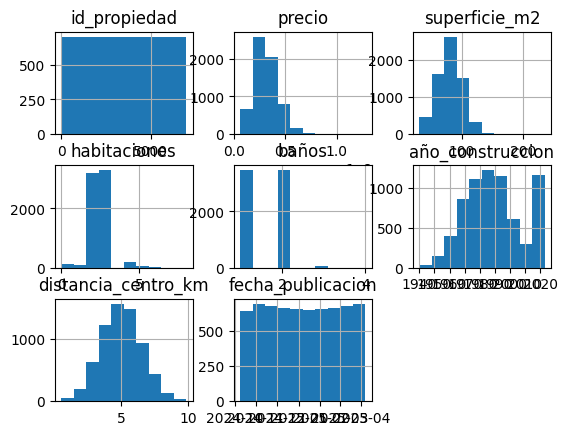

In [123]:
df_inmobiliario.hist()

In [124]:
df_inmobiliario[['id_propiedad', 'precio', 'superficie_m2', 'habitaciones', 'baños', 'distancia_centro_km']].corr()

,id_propiedad,precio,superficie_m2,habitaciones,baños,distancia_centro_km
id_propiedad,1.000000,-0.453111,-0.011965,-0.023787,-0.017019,-0.002943
precio,-0.453111,1.000000,0.702822,0.618647,0.571830,-0.003476
superficie_m2,-0.011965,0.702822,1.000000,0.861955,0.796946,-0.003094
habitaciones,-0.023787,0.618647,0.861955,1.000000,0.751996,0.002761
baños,-0.017019,0.571830,0.796946,0.751996,1.000000,0.006570
distancia_centro_km,-0.002943,-0.003476,-0.003094,0.002761,0.006570,1.000000


Como no es de extrañar, vemos una correlación alta entre:
- Precio y superficie_m2
- Superficie y habitaciones/baños
- Precio y habitaciones/baños

In [125]:
#Pintamos en un scatter el precio de los inmuebles para comprobar si hay outliers:
fig = px.scatter(
    df_inmobiliario,
    y= ['precio']
)

fig.show()

In [126]:
df_inmobiliario[df_inmobiliario['precio'] > 700000]

,id_propiedad,ciudad,barrio_distrito,tipo_operacion,tipo_inmueble,precio,superficie_m2,habitaciones,baños,estado,año_construccion,planta,ascensor,terraza,piscina,garaje,trastero,distancia_centro_km,fecha_publicacion,rango_m2
2,3,Madrid,Salamanca,Venta,Piso,821455.0,153.98,4.0,2.0,Buen estado,1996-01-01,3,False,True,False,False,False,5.13,2025-03-24,120-160
67,68,Madrid,Salamanca,Venta,Piso,1087781.0,208.01,6.0,3.0,Buen estado,1966-01-01,4,False,False,True,True,False,6.92,2024-10-18,200-240
134,135,Madrid,Madrid-Centro,Venta,Piso,821547.0,183.65,5.0,3.0,Buen estado,1992-01-01,4,False,False,False,False,False,4.28,2024-11-14,160-200
171,172,Madrid,Madrid-Centro,Venta,Piso,850997.0,170.99,5.0,3.0,Buen estado,1985-01-01,6,False,False,False,True,False,3.56,2025-02-09,160-200
585,586,Madrid,Retiro,Venta,Piso,716926.0,131.40,4.0,2.0,Buen estado,1989-01-01,6,True,False,False,False,True,4.89,2025-01-11,120-160
602,603,Madrid,Retiro,Venta,Piso,785945.0,85.00,3.0,2.0,Buen estado,2006-01-01,4,False,False,True,False,False,5.80,2025-02-11,80-120
683,684,Madrid,Madrid-Centro,Venta,Piso,747378.0,166.89,5.0,3.0,Buen estado,1959-01-01,6,False,True,False,False,False,3.05,2025-03-07,160-200
846,847,Madrid,Salamanca,Venta,Piso,710344.0,129.50,4.0,2.0,Buen estado,1979-01-01,2,True,True,False,True,False,3.81,2024-11-27,120-160
957,958,Madrid,Retiro,Venta,Piso,751692.0,131.80,4.0,2.0,Buen estado,1972-01-01,9,True,True,False,True,False,7.74,2025-03-17,120-160
987,988,Madrid,Arganzuela,Alquiler,Piso,774284.0,87.30,3.0,2.0,Buen estado,1974-01-01,4,True,False,False,False,False,6.05,2025-01-02,80-120


In [127]:
#Pintamos en un scatter la superficie m2 de los inmuebles para comprobar si hay outliers:
fig = px.scatter(
    df_inmobiliario,
    y= ['superficie_m2']
)

fig.show()

In [128]:
df_inmobiliario[df_inmobiliario['superficie_m2']>150]

,id_propiedad,ciudad,barrio_distrito,tipo_operacion,tipo_inmueble,precio,superficie_m2,habitaciones,baños,estado,año_construccion,planta,ascensor,terraza,piscina,garaje,trastero,distancia_centro_km,fecha_publicacion,rango_m2
2,3,Madrid,Salamanca,Venta,Piso,821455.0,153.98,4.0,2.0,Buen estado,1996-01-01,3,False,True,False,False,False,5.13,2025-03-24,120-160
67,68,Madrid,Salamanca,Venta,Piso,1087781.0,208.01,6.0,3.0,Buen estado,1966-01-01,4,False,False,True,True,False,6.92,2024-10-18,200-240
134,135,Madrid,Madrid-Centro,Venta,Piso,821547.0,183.65,5.0,3.0,Buen estado,1992-01-01,4,False,False,False,False,False,4.28,2024-11-14,160-200
171,172,Madrid,Madrid-Centro,Venta,Piso,850997.0,170.99,5.0,3.0,Buen estado,1985-01-01,6,False,False,False,True,False,3.56,2025-02-09,160-200
683,684,Madrid,Madrid-Centro,Venta,Piso,747378.0,166.89,5.0,3.0,Buen estado,1959-01-01,6,False,True,False,False,False,3.05,2025-03-07,160-200
989,990,Madrid,Chamberí,Venta,Piso,998925.0,206.71,6.0,3.0,Buen estado,1972-01-01,1,True,True,False,False,True,5.25,2025-02-02,200-240
1543,1544,Barcelona,Sarrià-Sant Gervasi,Venta,Piso,609842.0,150.90,4.0,2.0,Obra nueva,2020-01-01,7,True,False,False,True,True,1.46,2025-03-16,120-160
1791,1792,Barcelona,Sants-Montjuïc,Venta,Piso,589987.0,157.75,4.0,2.0,A reformar,1998-01-01,8,True,True,True,False,False,6.44,2025-01-07,120-160
2206,2207,Barcelona,Sarrià-Sant Gervasi,Venta,Piso,1025898.0,235.26,6.0,3.0,Buen estado,1977-01-01,1,False,True,False,False,False,6.59,2025-03-02,200-240
2277,2278,Barcelona,Sarrià-Sant Gervasi,Alquiler,Ático,741894.0,157.10,4.0,2.0,Buen estado,2009-01-01,Ático,True,True,False,False,True,7.14,2025-01-14,120-160


In [129]:
#Correlación entre ambas:
fig = px.scatter(
    df_inmobiliario,
    x= 'precio',
    y= 'superficie_m2'
)

fig.show()

La columna precio-superficie está muy correlada, por lo que podemos decir que una depende de la otra, como ya veníamos adelantando en la correción de datos.

Vemos que hay algunos outliers en las columnas "precios" y "superficie_m2", pero si los estudiamos vemos que son datos perfectamente válidos ya que el están acordes con el estado del inmueble, la planta, los barrios donde se encuentran y el resto de variables. De esta manera, aunque puedan irse de rango, no pueden ser considerados errores.

In [130]:
#Pintamos un boxplot el número de baños y habitaciones de los inmuebles para comprobar si hay outliers:
fig = px.box(
    df_inmobiliario,
    y= ['habitaciones', 'baños']
)

fig.show()

In [131]:
fig = px.scatter(
    df_inmobiliario,
    x= ['habitaciones', 'baños'],
    y= 'superficie_m2'
)

fig.show()

Las habitaciones y baños son datos corregidos. Vemos que hay outliers al igual que en el precio y superficie porque están correlados.

✅ **Conclusión sobre los outliers:**

Hay valores que no pueden ser considerados como datos erróneos, sino que están fuera del rango habitual al ser pisos con características un poco más diferentes que la media.

##📈 3.3. Variables clave + Análisis

Para las visualizaciones de este df_inmobiliario, vamos tener en cuenta los parámetros más interesantes a nivel inmobiliario, en los apartados que encontraremos a continuación.

###Porcentaje por tipo de inmueble

In [132]:
df_inmobiliario2 = df_inmobiliario['tipo_inmueble'].value_counts().reset_index()
df_inmobiliario2

,tipo_inmueble,count
0,Piso,5914
1,Ático,649
2,Sin_clasificar,309
3,Estudio,128


In [133]:
fig = px.pie(df_inmobiliario2,
             values = 'count',
             names = 'tipo_inmueble',
             title = "Porcentaje total por tipo de inmueble",
)

fig.update_traces(
    customdata=df_inmobiliario2[['count']],
    hovertemplate=(
        "<b>%{label}</b><br>" +
        "Total inmuebles: %{customdata[0]:,}<br>" +
        "<extra></extra>"
    )
)

fig.update_layout(title_x = 0.5)

fig.show()

###Tendencia de precios por fecha de publicación

In [134]:
df_inmobiliario1 = df_inmobiliario.groupby(['ciudad','barrio_distrito','fecha_publicacion']).agg(Precio = ('precio','mean')).reset_index()
df_inmobiliario1['Precio'] = df_inmobiliario1['Precio'].round(2)
df_inmobiliario1.head()

,ciudad,barrio_distrito,fecha_publicacion,Precio
0,Barcelona,Ciutat Vella,2024-10-13,516014.0
1,Barcelona,Ciutat Vella,2024-10-15,458325.0
2,Barcelona,Ciutat Vella,2024-10-17,359400.0
3,Barcelona,Ciutat Vella,2024-10-18,283811.0
4,Barcelona,Ciutat Vella,2024-10-21,271946.0


In [135]:
fig = go.Figure()

ciudades = df_inmobiliario1['ciudad'].unique()

trazas_por_ciudad = []
trace_labels = []

for ciudad in ciudades:
    df_ciudad = df_inmobiliario1[df_inmobiliario1['ciudad'] == ciudad]
    barrios = df_ciudad['barrio_distrito'].unique()
    ciudad_traces = []

    for barrio in barrios:
        df_barrio = df_ciudad[df_ciudad['barrio_distrito'] == barrio]
        fig.add_trace(go.Bar(
            x=df_barrio['fecha_publicacion'],
            y=df_barrio['Precio'],
            name=barrio,
            visible=(ciudad == ciudades[0]),
            customdata=df_barrio[['ciudad', 'barrio_distrito', 'Precio']],
            hovertemplate="<b>%{customdata[0]}</b><br>" +
                          "<b>%{customdata[1]}</b><br>" +
                          "Precio medio: %{customdata[2]:,.0f} €<br>" +
                          "<extra></extra>"
        ))
        ciudad_traces.append(len(fig.data) - 1)
        trace_labels.append((ciudad, barrio))

    trazas_por_ciudad.append(ciudad_traces)

buttons = []
for i, ciudad in enumerate(ciudades):
    visibility = [False] * len(fig.data)
    for idx in trazas_por_ciudad[i]:
        visibility[idx] = True

    buttons.append(dict(
        label=ciudad,
        method="update",
        args=[
            {"visible": visibility},
            {"title": f"Tendencia de precios por barrio - {ciudad}"}
        ]
    ))

fig.update_layout(
    updatemenus=[
        dict(
            buttons=buttons,
            direction="down",
            showactive=True,
            x=0.5,
            xanchor="center",
            y=1.1,
            yanchor="top"
        )
    ],
    barmode='stack',
    title=f"Tendencia de precios por barrio: {ciudades[0]}",
    title_x=0.5,
    xaxis_title="Fecha de publicación",
    yaxis_title="Precio inmueble (€)",
    height=600
)

fig.show()

###Antiguedad de los inmuebles por ciudad y barrio

In [136]:
#Visión general por ciudad:
fig = px.density_heatmap(
    df_inmobiliario,
    x = 'año_construccion',
    y = 'ciudad',
    title = 'Antiguedad del inmueble por ciudad',
    text_auto=True
)

fig.update_layout(title_x=0.5)
fig.update_layout(
    xaxis_title='Año de construcción',
    yaxis_title='Ciudad'
)

fig.show()

In [137]:
#Visión concreta por ciudades y sus barrios:

ciudades = df_inmobiliario['ciudad'].unique()

fig = go.Figure()

for ciudad in ciudades:
  df_ciudad = df_inmobiliario[df_inmobiliario['ciudad'] == ciudad]

  fig.add_trace(go.Histogram2d(
      x = df_ciudad['año_construccion'],
      y = df_ciudad['barrio_distrito'],
      name=ciudad,
      visible=(ciudad == ciudades[0]),
      hovertemplate="Año: %{x}<br>Barrio: %{y}<br>Frecuencia: %{z}<extra></extra>"
  ))

buttons = []
for i, ciudad, in enumerate(ciudades):
  visibilidad = [j == i for j in range(len(ciudades))]
  buttons.append(dict(
        label=ciudad,
        method="update",
        args=[{"visible": visibilidad},
              {"title": f"Antigüedad del inmueble por barrio - {ciudad}"}]
    ))

fig.update_layout(
    updatemenus=[dict(
        buttons=buttons,
        direction="down",
        showactive=True,
        x=0.5,
        xanchor="center",
        y=1.1,
        yanchor="top"
    )],
    title=f"Antigüedad del inmueble por barrio: {ciudades[0]}",
    title_x=0.5,
    xaxis_title='Año de construcción',
    yaxis_title='Barrio',
    height=600
)

fig.show()

###Comparativa de precios de venta vs alquiler

In [138]:
df_inmobiliario3 = df_inmobiliario.groupby('tipo_operacion').agg({'precio': 'mean'}).reset_index()
df_inmobiliario3= df_inmobiliario3.round(2)
df_inmobiliario3

,tipo_operacion,precio
0,Alquiler,314274.45
1,Venta,313662.73


In [139]:
fig = px.pie(
    df_inmobiliario3,
    values='precio',
    names='tipo_operacion',
    title = "Proporción de media de precios Alquiler vs Ventas",
    color_discrete_sequence=px.colors.sequential.RdBu,
)

fig.update_traces(
    customdata=df_inmobiliario3[['precio']],
    hovertemplate =(
        "<b>%{label}</b><br>" +
        "Precio medio: %{customdata[0]:,.2f} €<br>" +
        "<extra></extra>"
    )
)

fig.update_layout(title_x = 0.5)

fig.show()

##📝 3.4. Conclusiones sobre el df_inmobiliario

Resumen:
- La mayoría de los inmuebles son pisos, cosa que no es de extrañar en una ciudad que está formada mayoritariamente por ellos. Proporcionalmente siempre habrá menos Áticos y Estudios que pisos en una ciudad.
- Desde 2024 que tenemos primeros registros de publicación de inmuebles, no vemos que los pisos hayan subido o bajado su precio drásticamente.
- La ciudad donde más se ha construido es Madrid, y que ha sido sobretodo en los años 80 y 90, y que ha despuntado desde 2020. Aunque todas las ciudades han tenido un auge de construcción alrededor de esos años.
- Los precios de venta y alquiler son proporcionalmente iguales.

Podemos concluir que los datos de este dataframe sí son fiables, y que por lo tanto podremos obtener insights y oportunidades de negocio a partir de ellos.

#📎 4. EDA TIPO

## 🔍 4.1. Carga y comprensión inicial del dataset

Vamos a visualizar el df de Tipo. Para ello, vamos a:
- Ver una muestra con el .head() con el objetivo de ver las columnas del dataframe y los valores que nos podemos encontrar dentro de él.
- Ver la cantidad de filas y columnas con el .shape.
- Ver un resumen con la información de las columnas, para ver el tipo de datos y si hay nulos en cada una de ellas, con el .info().
- Ver un .describe() para ver las estadísticas básicas de los datos.

In [140]:
df_tipo

,tipo_inmueble,descripcion
0,Piso,"Apartamento en edificio, usualmente con varias..."
1,Estudio,"Vivienda de planta única, generalmente compacta."
2,Dúplex,Apartamento de dos niveles comunicados mediant...
3,Ático,"Piso en la última planta, con vistas y terraza."
4,Chalet,"Casa independiente, a menudo con jardín y mayo..."


In [141]:
df_tipo.shape

(5, 2)

In [142]:
df_tipo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   tipo_inmueble  5 non-null      object
 1   descripcion    5 non-null      object
dtypes: object(2)
memory usage: 212.0+ bytes


In [143]:
df_tipo.describe()

,tipo_inmueble,descripcion
count,5,5
unique,5,5
top,Piso,"Apartamento en edificio, usualmente con varias..."
freq,1,1


##📊 3.2. Limpieza de los datos

En este caso, hemos podido ver en el .info() que todos los datos son correctos, que no hay nulos y que tienen el tipo correcto.

###Estandarizar datos

In [144]:
def limpiar_inconsistencias(df_tipo):
  df_tipo.columns=(
        df_tipo.columns
        .str.strip()
        .str.lower()
        .str.replace(' ', '_')
        .str.replace(r'[^\w_]', '', regex=True)
    )
  for col in df_tipo.select_dtypes(include='object').columns:
        df_tipo[col] = (
            df_tipo[col]
            .astype(str)
            .str.strip()
            .str.replace(r'\s+', ' ', regex=True)
        )

  return df_tipo

In [145]:
df_tipo = limpiar_inconsistencias(df_tipo)

###Tratamiento de valores nulos

In [146]:
df_tipo.isnull().sum()

,0
tipo_inmueble,0
descripcion,0


###Tratamiento de duplicados

Vamos a comprobar si hay algún valor duplicado en la columna "tipo_inmueble", que es la que tiene los valores únicos en el dataframe.

In [147]:
df_tipo['tipo_inmueble'].duplicated().sum()

np.int64(0)

## 📈 4.3. Variables clave + Análisis

Como no tenemos datos numéricos en este df, no vamos a pintar gráficos para hacer un EDA. Lo que haremos será analizar estos datos uniéndolos con los otros df según nos convenga.

#📎 5. Ejes de análisis de negocio

##📉 5.1. Precio por metro cuadrado

### Análisis de la variación del precio por m2 entre ciudades y barrios

Tenemos varios dataframes de los que podemos obtener esta información:
- df_barrios
- df_ciudades
- df_inmobiliario


In [148]:
#DF_BARRIOS
df_barrios1 = df_barrios.groupby('ciudad').agg({'precio_m2_barrio': 'mean'}).sort_values('precio_m2_barrio', ascending=False).reset_index()
df_barrios1['precio_m2_barrio'] = df_barrios1['precio_m2_barrio'].round(2)
df_barrios1= df_barrios1.rename(columns={'precio_m2_barrio': 'precio_m2_media'})
df_barrios1

,ciudad,precio_m2_media
0,Barcelona,6228.20
1,Sevilla,6215.00
2,Valencia,6059.20
3,Madrid,5149.00
4,Málaga,5147.75
5,Bilbao,4894.00
6,Zaragoza,4878.75


In [149]:
#DF_CIUDADES
df_ciudades2 = df_ciudades.groupby('ciudad').agg({'precio_m2_medio':'mean'}).sort_values("precio_m2_medio", ascending = False).reset_index()
df_ciudades2

,ciudad,precio_m2_medio
0,Madrid,5000.0
1,Barcelona,4500.0
2,Bilbao,4000.0
3,Málaga,3500.0
4,Sevilla,3200.0
5,Valencia,3000.0
6,Zaragoza,2800.0


In [150]:
#DF_INMOBILIARIO
df_inmobiliario['precio_m2'] = (df_inmobiliario['precio'] / df_inmobiliario['superficie_m2']).round(2)

df_inmobiliario1 = df_inmobiliario.groupby('ciudad').agg({'precio_m2':'mean'}).sort_values("precio_m2", ascending = False).reset_index()
df_inmobiliario1 = df_inmobiliario1.round(2)
df_inmobiliario1

,ciudad,precio_m2
0,Madrid,5011.95
1,Barcelona,4507.93
2,Bilbao,4004.08
3,Málaga,3531.43
4,Sevilla,3229.51
5,Valencia,3010.45
6,Zaragoza,2808.91


Confirmamos que los datos correctos son los de df_ciudades y df_inmobiliario, y que por tanto no podemos usar como referencia el df_barrios para las preguntas de negocio.

Para comprobar los datos por barrio, accederemos al df_inmobiliario que es el que tiene esta información de forma más específica

In [151]:
df_inmobiliario2 = df_inmobiliario.groupby(['ciudad', 'barrio_distrito']).agg({'precio_m2':'mean'}).sort_values("precio_m2", ascending = False).reset_index()
df_inmobiliario2 = df_inmobiliario2.round(2)
df_inmobiliario2.head()

,ciudad,barrio_distrito,precio_m2
0,Madrid,Retiro,5043.20
1,Madrid,Salamanca,5018.59
2,Madrid,Chamberí,5015.70
3,Madrid,Madrid-Centro,5010.98
4,Madrid,Tetuán,5006.98


In [152]:
fig = px.bar(
    df_inmobiliario2,
    y= "precio_m2",
    x = "barrio_distrito",
    color = "ciudad",
    title= "Tendencia del precio por m2 por barrio y ciudades",
    custom_data = ['ciudad', 'precio_m2'],
    hover_data= {'ciudad':False}
)

fig.update_traces(
    hovertemplate = (
        "%{customdata[0]}<br>" +
        "Precio por m2 = %{customdata[1]:,.0f} €<br>" +
        "<extra></extra>"
    )
)

fig.update_layout(title_x=0.5)
fig.update_layout(xaxis_title= "Precio m2 cuadrado",
                  yaxis_title = "Barrio/Distrito")

fig.show()

📌 **Conclusiones**

Sin haber analizado ningún factor más, podemos ver que los mercados de Madrid y Barcelona son los más saturados, pero en los que más dinero hay. Sin embargo, sin tener más datos, podríamos decir que las oportunidades de inversión estarían en las ciudades más baratas y que podrían llegar a revalorizarse por su crecimiento económico, como puede ser Valencia, Sevilla y Málaga.

##📉 5.2. Impacto de los servicios urbanos

El impacto de los servicios urbanos es un dato que se encuentra exclusivamente en el df_barrios. Sin embargo, como ya hemos visto en su análisis, es un dataframe del que no podemos obtener datos fiables, ya que la columna "barrio_distrito" no está bien categorizada ni podemos categorizarla bien porque los datos de coordenadas son incorrectos.

Además, sospechábamos que muchos datos podían ser incorrectos y por ello no nos darían un insight adecuado.

Vamos a analizar el impacto de los servicios igualmente para confirmarlo.

###Relación del nivel de servicios con el precio y la renta del barrio

In [153]:
relacion_servicios = df_barrios.groupby('nivel_servicios')[['renta_media', 'precio_m2_barrio']].mean().reset_index()
relacion_servicios = relacion_servicios.round(2)
relacion_servicios

,nivel_servicios,renta_media,precio_m2_barrio
0,Alto,25644.91,5021.36
1,Bajo,33425.83,6421.17
2,Medio,26714.50,5582.88


In [154]:
fig= px.bar(
    relacion_servicios,
    x = 'nivel_servicios',
    y = ['renta_media', 'precio_m2_barrio'],
    barmode='group',
    title="Nivel de servicios según la renta y precio m2",
)

fig.update_layout(title_x=0.5)
fig.update_layout(
    xaxis_title='Nivel de servicios',
    yaxis_title='Valor Medio'
)

fig.show()

Como vemos, estos datos no deberían ser concluyentes porque no tiene sentido que las zonas con un nivel de servicios "Bajo" sean las que mayor renta y precio por m2 tengan.

###Relación del nivel de servicios con los índices

¿La presencia de más servicios influye en una mayor o menor accesibilidad y seguridad?

In [155]:
relacion_indices = df_barrios.groupby('nivel_servicios')[['indice_seguridad','indice_accesibilidad']].mean().reset_index()
relacion_indices = relacion_indices.round(2)
relacion_indices

,nivel_servicios,indice_seguridad,indice_accesibilidad
0,Alto,7.36,6.83
1,Bajo,6.60,6.72
2,Medio,6.10,7.51


In [156]:
fig= px.bar(
    relacion_indices,
    x = 'nivel_servicios',
    y = ['indice_seguridad','indice_accesibilidad'],
    barmode='group',
    title="Índices de seguridad y accesibilidad según el nivel de servicios",
)

fig.update_layout(title_x=0.5)
fig.update_layout(
    xaxis_title='Nivel de servicios',
    yaxis_title='Valor Medio'
)

fig.show()

Vemos que este dato tampoco es concluyente, ya que no hay una gran diferencia entre el nivel de servicios y los índices.

📌 **Conclusión**

No podemos medir el impacto de los servicios urbanos por barrio ya que no tenemos datos fiables ni correctos.

##📉 5.3.  Características de la propiedad

###Distribución de los inmuebles

Vamos a examinar la distribución de tipos de inmuebles, número de habitaciones, baños, y equipamientos (ascensor, terraza, piscina, etc), para tener una mejor idea sobre el df_inmuebles.

Tenemos que tener en cuenta que los datos de habitaciones y baños fueron corregidos, y que por tanto son una aproximación, pero no un valor real. De esta manera, no lo vamos a incluir en el análisis.

In [157]:
df_inmobiliario2 = df_inmobiliario['tipo_inmueble'].value_counts().reset_index()
df_inmobiliario2

,tipo_inmueble,count
0,Piso,5914
1,Ático,649
2,Sin_clasificar,309
3,Estudio,128


In [158]:
fig = px.pie(df_inmobiliario2,
             values = 'count',
             names = 'tipo_inmueble',
             title = "Porcentaje total por tipo de inmueble",
)

fig.update_traces(
    customdata=df_inmobiliario2[['count']],
    hovertemplate=(
        "<b>%{label}</b><br>" +
        "Total inmuebles: %{customdata[0]:,}<br>" +
        "<extra></extra>"
    )
)

fig.update_layout(title_x = 0.5)

fig.show()

###Estudio del equipamiento

In [159]:
equipamiento_inm = df_inmobiliario.groupby('tipo_inmueble')[['ascensor','terraza', 'piscina', 'garaje', 'trastero']].mean().reset_index()
equipamiento_inm

,tipo_inmueble,ascensor,terraza,piscina,garaje,trastero
0,Estudio,0.648438,0.460938,0.242188,0.453125,0.351562
1,Piso,0.648630,0.481569,0.273081,0.461109,0.359148
2,Sin_clasificar,0.666667,0.407767,0.252427,0.394822,0.391586
3,Ático,0.608629,0.485362,0.255778,0.443760,0.355932


In [160]:
fig = px.bar(
    equipamiento_inm,
    x = 'tipo_inmueble',
    y = ['ascensor','terraza', 'piscina', 'garaje', 'trastero'],
    title="Equipamiento por tipo de vivienda",
    barmode = 'group'
)

fig.update_layout(title_x=0.5)
fig.update_layout(
    xaxis_title='Tipo de inmueble',
    yaxis_title='% Equipamiento'
)

fig.show()

In [161]:
equipamiento_rang = df_inmobiliario.groupby('rango_m2')[['ascensor','terraza', 'piscina', 'garaje', 'trastero']].mean().reset_index()
equipamiento_rang

/tmp/ipython-input-4149136453.py:1: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



,rango_m2,ascensor,terraza,piscina,garaje,trastero
0,0-40,0.618056,0.472222,0.222222,0.437500,0.354167
1,40-80,0.651682,0.478978,0.274903,0.456986,0.369017
2,80-120,0.637182,0.484482,0.273122,0.460894,0.351335
3,120-160,0.709091,0.496970,0.206061,0.472727,0.303030
4,160-200,0.541667,0.458333,0.166667,0.541667,0.500000
5,200-240,0.666667,0.833333,0.166667,0.333333,0.500000


In [162]:
fig = px.bar(
    equipamiento_rang,
    x = 'rango_m2',
    y = ['ascensor','terraza', 'piscina', 'garaje', 'trastero'],
    title="Equipamiento por rango m2",
    barmode = 'group'
)

fig.update_layout(title_x=0.5)
fig.update_layout(
    xaxis_title='Tipo de inmueble',
    yaxis_title='% Equipamiento'
)

fig.show()

In [163]:
precio_inversion = df_inmobiliario.groupby('tipo_operacion')[['ascensor','terraza', 'piscina', 'garaje', 'trastero']].mean().reset_index()
precio_inversion

,tipo_operacion,ascensor,terraza,piscina,garaje,trastero
0,Alquiler,0.633414,0.483293,0.258596,0.456174,0.342373
1,Venta,0.650861,0.476190,0.274772,0.456535,0.367579


In [164]:
fig = px.bar(
    precio_inversion,
    x = 'tipo_operacion',
    y = ['ascensor','terraza', 'piscina', 'garaje', 'trastero'],
    title="Equipamiento por tipo de operación",
    barmode = 'group'
)

fig.update_layout(title_x=0.5)
fig.update_layout(
    xaxis_title='Tipo de operación',
    yaxis_title='% Equipamiento'
)

fig.show()

###Precio medio por tipo de inmueble

In [165]:
precio_inm = df_inmobiliario.groupby('tipo_inmueble')['precio'].mean().reset_index()
precio_inm = precio_inm[precio_inm['tipo_inmueble'] != 'Sin_clasificar']
precio_inm = precio_inm.round(2)
precio_inm

,tipo_inmueble,precio
0,Estudio,128073.87
1,Piso,317700.24
3,Ático,315337.08


In [166]:
fig= px.bar(
    precio_inm,
    x= 'tipo_inmueble',
    y = 'precio',
    text = 'precio',
    title = "Media de precio por tipo de inmueble",
    custom_data = ['tipo_inmueble', 'precio'],
)

fig.update_layout(title_x=0.5)
fig.update_layout(
    xaxis_title='Tipo de inmueble',
    yaxis_title='Precio €'
)

fig.update_traces(
    hovertemplate = (
        "%{customdata[0]}<br>" +
        "Precio por m2 = %{customdata[1]:,.0f} €<br>" +
        "<extra></extra>"
    )
)

fig.show()

In [167]:
precio_rang = df_inmobiliario.groupby('rango_m2')['precio'].mean().reset_index()
precio_rang = precio_rang.round(2)
precio_rang

/tmp/ipython-input-3329723625.py:1: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



,rango_m2,precio
0,0-40,128405.10
1,40-80,253553.75
2,80-120,366529.93
3,120-160,509488.15
4,160-200,607088.38
5,200-240,898621.00


In [168]:
fig= px.line(
    precio_rang,
    x= 'rango_m2',
    y = 'precio',
    title = "Media de precio por superficie",
    custom_data = ['rango_m2', 'precio'],
)

fig.update_layout(title_x=0.5)
fig.update_layout(
    xaxis_title='Rango m2',
    yaxis_title='Precio €'
)

fig.update_traces(
    hovertemplate = (
        "%{customdata[0]}<br>" +
        "Precio por m2 = %{customdata[1]:,.0f} €<br>" +
        "<extra></extra>"
    )
)

fig.show()

###Estado y precio del inmueble

In [169]:
tipo_inmueble_freq=('estado', lambda x: x.value_counts().idxmax())

In [170]:
estado_por_ciudad = df_inmobiliario.groupby(['ciudad','estado']).size().reset_index(name='cantidad')
estado_por_ciudad.head()

,ciudad,estado,cantidad
0,Barcelona,A reformar,66
1,Barcelona,Buen estado,835
2,Barcelona,Obra nueva,185
3,Barcelona,Reformado,114
4,Bilbao,A reformar,53


In [171]:
fig = px.bar(
    estado_por_ciudad,
    x='ciudad',
    y='cantidad',
    color='estado',
    title='Proporción de inmuebles por estado y ciudad',
    barmode='stack',
    text='cantidad'
)

fig.update_layout(title_x=0.5)
fig.show()

In [172]:
estado_por_ciudad = df_inmobiliario.groupby(['barrio_distrito', 'estado']).size().reset_index(name='cantidad')
estado_por_ciudad

,barrio_distrito,estado,cantidad
0,Abando,A reformar,9
1,Abando,Buen estado,140
2,Abando,Obra nueva,19
3,Abando,Reformado,18
4,Arganzuela,A reformar,15
...,...,...,...
127,Triana,Reformado,13
128,Zaragoza_Centro,A reformar,7
129,Zaragoza_Centro,Buen estado,131
130,Zaragoza_Centro,Obra nueva,28


In [173]:
fig = px.bar(
    estado_por_ciudad,
    x='barrio_distrito',
    y='cantidad',
    color='estado',
    title='Proporción de inmuebles por estado y ciudad',
    barmode='stack',
    text='cantidad'
)

fig.update_layout(title_x=0.5)
fig.show()

In [174]:
estado_por_inmueble = df_inmobiliario.groupby(['tipo_inmueble','estado']).size().reset_index(name='cantidad')
estado_por_inmueble.head()

,tipo_inmueble,estado,cantidad
0,Estudio,A reformar,5
1,Estudio,Buen estado,91
2,Estudio,Obra nueva,20
3,Estudio,Reformado,12
4,Piso,A reformar,278


In [175]:
tipos = estado_por_inmueble['tipo_inmueble'].unique()

for tipo in tipos:
  if tipo != 'Sin_clasificar':
    df_filtrado = estado_por_inmueble[estado_por_inmueble['tipo_inmueble'] == tipo]
    fig = px.pie(
        df_filtrado,
        names='estado',
        values='cantidad',
        title=f"Distribución del estado para: {tipo}"
    )

    fig.show()

📌 **Conclusiones**

- La distribución de los equipamientos (ascensor, terraza, piscina, etc) es prácticamente la misma por tipo de inmueble y tipo de operación. Sin embargo, vemos una variación concreta según el rango de m2: los inmuebles que tienen mayor superficie tienden a tener terrazas en mayor medida.
- Los precios entre pisos y áticos son muy similares entre sí. Sin embargo, vemos que los estudios tienen un precio más barato, lo que tiene sentido al ser una estancia más pequeña.
- Los precios suben según la superficie es mayor.
- En proporción, el estado de los pisos se parece en todas las ciudades. Sin embargo, vemos que hay algunos barrios como Arganzuela, Ciutat Vella, Deusto y Gràcia que tienen más pisos a reformar que el resto.
- La distribución del estado por el tipo de pisos está muy igualada: solo un 4-5% de los pisos están para reformar.

##📉 5.4. Análisis temporal y geográfico

### Tendencias por fecha de publicación

Vamos a considerar la fecha de publicacion para analizar tendencias a lo largo del tiempo.

In [176]:
df_inm_trend = df_inmobiliario.groupby([pd.Grouper(key='fecha_publicacion', freq='M'),'tipo_operacion']).agg(precio_medio = ('precio', 'mean'), cantidad = ('id_propiedad', 'count')).reset_index()
df_inm_trend = df_inm_trend.round(2)
df_inm_trend

/tmp/ipython-input-3411752158.py:1: FutureWarning:

'M' is deprecated and will be removed in a future version, please use 'ME' instead.



,fecha_publicacion,tipo_operacion,precio_medio,cantidad
0,2024-10-31,Alquiler,315773.32,224
1,2024-10-31,Venta,316698.04,603
2,2024-11-30,Alquiler,328244.70,359
3,2024-11-30,Venta,304434.60,807
4,2024-12-31,Alquiler,311240.24,335
5,2024-12-31,Venta,315100.77,809
6,2025-01-31,Alquiler,323818.79,337
7,2025-01-31,Venta,306455.75,786
8,2025-02-28,Alquiler,312130.76,307
9,2025-02-28,Venta,318166.94,717


In [177]:
fig = px.line(
    df_inm_trend,
    x='fecha_publicacion',
    y='precio_medio',
    color='tipo_operacion',
    title='Evolución del precio medio según el tipo de operación',
    labels={'fecha_publicacion': 'Fech de publicación', 'precio_medio': 'Precio medio'}
)

fig.update_layout(title_x=0.5)

fig.show()

In [178]:
fig2 = px.bar(
    df_inm_trend,
    x='fecha_publicacion',
    y='cantidad',
    color='tipo_operacion',
    barmode='group',
    title='Cantidad de anuncios según tipo de operación en el tiempo',
    labels={'fecha_publicacion': 'Fecha', 'cantidad': 'Número de anuncios'}
)
fig2.update_layout(title_x=0.5)
fig2.show()

Vamos volver a pintar este gráfico para ver también las tendencias por ciudad y barrio, que nos dará otra perspectiva.

In [179]:
df_inmobiliario1 = df_inmobiliario.groupby(['ciudad','barrio_distrito','fecha_publicacion']).agg(Precio = ('precio','mean')).reset_index()
df_inmobiliario1['Precio'] = df_inmobiliario1['Precio'].round(2)
df_inmobiliario1.head()

,ciudad,barrio_distrito,fecha_publicacion,Precio
0,Barcelona,Ciutat Vella,2024-10-13,516014.0
1,Barcelona,Ciutat Vella,2024-10-15,458325.0
2,Barcelona,Ciutat Vella,2024-10-17,359400.0
3,Barcelona,Ciutat Vella,2024-10-18,283811.0
4,Barcelona,Ciutat Vella,2024-10-21,271946.0


In [180]:
fig = go.Figure()

ciudades = df_inmobiliario1['ciudad'].unique()

trazas_por_ciudad = []
trace_labels = []

for ciudad in ciudades:
    df_ciudad = df_inmobiliario1[df_inmobiliario1['ciudad'] == ciudad]
    barrios = df_ciudad['barrio_distrito'].unique()
    ciudad_traces = []

    for barrio in barrios:
        df_barrio = df_ciudad[df_ciudad['barrio_distrito'] == barrio]
        fig.add_trace(go.Bar(
            x=df_barrio['fecha_publicacion'],
            y=df_barrio['Precio'],
            name=barrio,
            visible=(ciudad == ciudades[0]),
            customdata=df_barrio[['ciudad', 'barrio_distrito', 'Precio']],
            hovertemplate="<b>%{customdata[0]}</b><br>" +
                          "<b>%{customdata[1]}</b><br>" +
                          "Precio medio: %{customdata[2]:,.0f} €<br>" +
                          "<extra></extra>"
        ))
        ciudad_traces.append(len(fig.data) - 1)
        trace_labels.append((ciudad, barrio))

    trazas_por_ciudad.append(ciudad_traces)

buttons = []
for i, ciudad in enumerate(ciudades):
    visibility = [False] * len(fig.data)
    for idx in trazas_por_ciudad[i]:
        visibility[idx] = True

    buttons.append(dict(
        label=ciudad,
        method="update",
        args=[
            {"visible": visibility},
            {"title": f"Tendencia de precios por barrio - {ciudad}"}
        ]
    ))

# Añadir menú
fig.update_layout(
    updatemenus=[
        dict(
            buttons=buttons,
            direction="down",
            showactive=True,
            x=0.5,
            xanchor="center",
            y=1.1,
            yanchor="top"
        )
    ],
    barmode='stack',
    title=f"Tendencia de precios por barrio: {ciudades[0]}",
    title_x=0.5,
    xaxis_title="Fecha de publicación",
    yaxis_title="Precio inmueble (€)",
    height=600
)

fig.show()

###Distribución geográfica

Como las coordenadas por ciudad son las únicas correctas, y las tenemos en el df_ciudades, vamos a hacer un merge de ambos dataframes para que df_ciudad tenga información sobre los tipos de inmueble.

In [181]:
datos_merge = df_inmobiliario.groupby('ciudad').agg(
    superficie_m2_media=('superficie_m2', np.mean),
    tipo_inmueble_freq=('tipo_inmueble', lambda x: x.value_counts().idxmax()),
    media_habitaciones=('habitaciones', np.mean),
    media_baños=('baños', np.mean)
).reset_index()

datos_merge

/tmp/ipython-input-1868663160.py:1: FutureWarning:

The provided callable <function mean at 0x7ff9c3164220> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.

/tmp/ipython-input-1868663160.py:1: FutureWarning:

The provided callable <function mean at 0x7ff9c3164220> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.



,ciudad,superficie_m2_media,tipo_inmueble_freq,media_habitaciones,media_baños
0,Barcelona,81.657752,Piso,2.507937,1.522102
1,Bilbao,81.144331,Piso,2.497494,1.503759
2,Madrid,80.936754,Piso,2.530394,1.524382
3,Málaga,79.888336,Piso,2.455587,1.484241
4,Sevilla,80.996555,Piso,2.524048,1.511044
5,Valencia,81.728032,Piso,2.520040,1.517588
6,Zaragoza,80.827188,Piso,2.479950,1.514393


In [182]:
df_ciudades = df_ciudades.merge(datos_merge, on='ciudad', how='left')

In [183]:
df_ciudades

,ciudad,comunidad_autonoma,poblacion,superficie_km2,precio_m2_medio,latitud_centro,longitud_centro,superficie_m2_media,tipo_inmueble_freq,media_habitaciones,media_baños
0,Madrid,Madrid,3300000,604.3,5000,40.4168,-3.7038,80.936754,Piso,2.530394,1.524382
1,Barcelona,Cataluña,1600000,101.9,4500,41.3851,2.1734,81.657752,Piso,2.507937,1.522102
2,Valencia,Comunidad Valenciana,800000,134.6,3000,39.4699,-0.3763,81.728032,Piso,2.520040,1.517588
3,Sevilla,Andalucía,700000,140.0,3200,37.3891,-5.9845,80.996555,Piso,2.524048,1.511044
4,Bilbao,País Vasco,345000,41.6,4000,43.2630,-2.9350,81.144331,Piso,2.497494,1.503759
5,Málaga,Andalucía,578000,398.0,3500,36.7213,-4.4214,79.888336,Piso,2.455587,1.484241
6,Zaragoza,Aragón,675000,973.0,2800,41.6488,-0.8891,80.827188,Piso,2.479950,1.514393


In [184]:
fig = px.scatter_map(
    df_ciudades,
    lat= 'latitud_centro',
    lon='longitud_centro',
    color= "precio_m2_medio",
    size= "superficie_m2_media",
    zoom=4.5,
    color_continuous_scale=px.colors.cyclical.IceFire,
    title = 'Mapa de datos inmobiliarios por ciudad',
    hover_data = {'ciudad': True,
                  'comunidad_autonoma': True,
                  'precio_m2_medio': True,
                  'superficie_km2' : False,
                  'poblacion': False,
                  'latitud_centro':False,
                  'longitud_centro': False,
                  'superficie_m2_media' : True,
                  'tipo_inmueble_freq': True,
                  'media_habitaciones': True,
                  'media_baños': True}
)

fig.update_traces(
    hovertemplate=(
        "<b>%{customdata[0]}</b><br>" +
        "<b>%{customdata[1]}</b><br>" +
        "Precio m² medio: %{customdata[2]:,.0f} €<br>" +
        "Superficie m2 media: %{customdata[7]:,.1f} m²<br>" +
        "Tipo de inmueble más frecuente: %{customdata[8]}<br>" +
        "Media de habitaciones: %{customdata[9]:,.0f}<br>" +
        "Media de baños: %{customdata[10]:,.0f}<br>"

    )
)

fig.update_layout(title_x = 0.5)

fig.show()

📌 **Conclusiones**

- Se puede observar que en las fechas donde se publican más alquileres, es donde descienden los anuncios de venta de inmuebles y viceversa.
- Tiene sentido que en diciembre/febrero aumenten las ofertas de alquileres, sobretodo para estudiantes que dejan en esas fechas los inmuebles porque terminan y empiezan un semestre de universidad.
- La cantidad de anuncios desciende drásticamente en mayo de 2025, podríamos suponer porque son los últimos registros que se han tenido hasta mitad del mes.
- La tendencia de precio por barrio y ciudad es variable pero a rasgos generales no ha tenido ninguna subida ni descenso drástico, por lo que podemos decir que los precios se mantienen.
- Hay más anuncios de inmuebles en venta que en alquiler.

## 📉 5.5. Conclusiones

###Resumen del Análisis Exploratorio

Después de hacer un EDA de cada uno de los dataframes y habiendo analizado los ejes generales de negocio, determinamos que:
- El dataframe de los barrios habría sido muy útil para obtener información relevante sobre los mismos. Sin embargo, sus datos no estaban bien categorizados, y no había forma de volver a cateogrizarlos para poder analizarlos correctamente.
- El dataframe de las ciudades es el que más ha ayudado a ver la comparación geográfica, ya que es el que tenía coordenadas y resúmenes correctos sobre los datos de cada ciudad.
- El dataframe de los inmuebles tenía varias columnas mal categorizadas, como "tipo_inmueble". Sin embargo, gracias a datos de otras columnas se ha podido re-categorizar de manera correcta, a pesar de haber perdido el dato de los dúplex. En cuanto a las columnas de "habitaciones" y "baños", los datos no estaban correctos, y no había manera exacta de re-categorizarlos con datos del dataframe. Así que, en base a la superficie del inmueble, se ha puesto una aproximación realista del número de habitaciones y baños que cada inmueble podría tener.
- El dataframe de los tipos simplemente ha ayudado a entender la descripción de los tipos de inmueble.

###Oportunidades y vulnerabilidades

Teniendo una buena idea de todos los datos, vamos analizar las oportunidades y vulnerabilidades de inversión.

**Oportunidades de inversión:**
- Madrid y Barcelona son las ciudades donde, si se tiene un presupuesto alto para invertir, puede suponer una gran oportunidad para obtener casas. Son las capitales financieras de España, y la demanda de pisos es muy alta, con una tendencia que va en aumento porque cada vez más extranjeros se asientan en ellas. Por lo que siempre va a ser un acierto invertir aquí.
- Si nos centramos en el tipo de inmueble, los áticos tienen un precio medio igual que los pisos, lo que podría ser una oportunidad si se busca un piso acomodado a un precio único.
- Los barrios donde más pisos para reformar hay son en Arganzuela, Ciutat Vella, Deusto y Gràcia. Sitios con muy buena localización en los que es una muy buena oportunidad invertir para reformar. Pueden suponer una gran oportunidad para poder volver a venderlas a un precio mayor, ya que el precio por m2 es de los más altos de España.
- En cambio, Zaragoza y Valencia son las ciudades con el precio m2 más barato y asequible. La gran mayoría de pisos en ambas ciudades están en buen estado, de obra nueva o reformados. Por lo que si no tenemos un presupuesto tan alto, y buscamos pisos más grandes y céntricos, son muy buena opción de inversión.
- En concreto, Zaragoza es una ciudad que todavía no está tan masificada como el resto de ciudades, contando con la mayor superficie y con una población muy baja. Puede ser una gran oportunidad actual, ya que la tendencia de precios del mercado no parece que vaya a parar a de subir.


**Vulnerabilidades:**
- Los mercados de Madrid y Barcelona son muy caros y están muy saturados. Si lo que se busca es una casa con precio medio y una superficie de más de 80m2, el presupuesto que hay que tener es elevado. Por lo que son ciudades atractivas para inversores, pero no para familias.
- Bilbao es la ciudad con menos población y superficie. Tiene menos inmuebles y los que hay son bastante caros. Lo consideraría una ciudad poco atractiva para invertir ya que tiene un precio elevado, pero a la vez no es una capital financiera como lo es Madrid o Barcelona.





###Insights

A rasgos generales, invertir en inmuebles es un negocio muy rentable sea la ciudad que sea. Hay variables que pueden ayudar a tomar una decisión según el presupuesto que se tenga, la ciudad donde residas, el tipo de inmueble que quieras (más pequeño pero más céntrico, más grande pero a las afueras) y los motivos de compra.

Sin embargo, nos podremos ayudar de este análisis para tomar decisiones basadas en datos reales.

#📂 6. Exportación de los csv

In [185]:
df_barrios.to_csv("barrios_clean.csv", index=False)
df_ciudades.to_csv("ciudades_clean.csv", index=False)
df_inmobiliario.to_csv("inmobiliario_clean.csv", index=False)
df_tipo.to_csv("tipo_clean.csv", index=False)

#📚 7. Fuentes y Referencias

Bilbao.eus, Corporación y Gobierno, El Gobierno Municipal, Distritos. (n.d.). Bilbao.eus. Retrieved June 8, 2025, from https://www.bilbao.eus/cs/Satellite?cid=3000017134&language=es&pagename=Bilbaonet%2FPage%2FBIO_contenidoFinal

de Informática, C.-C. M. (n.d.). Distritos. Web Del Ayuntamiento de Málaga. Retrieved June 8, 2025, from https://www.malaga.eu/identidad/distritos/

de Transparencia y Gobierno Abierto, O. (n.d.). Juntas municipales y vecinales. Ayuntamiento de Zaragoza. Zaragoza.Es. Retrieved June 8, 2025, from https://www.zaragoza.es/sede/portal/participacion/en-tu-barrio/servicio/distrito/

Distritos - València. (n.d.). Valencia.es. Retrieved June 8, 2025, from https://www.valencia.es/cas/distritos

Distritos Municipales. (n.d.). Ayuntamiento de Sevilla. Retrieved June 8, 2025, from https://www.sevilla.org/distritos

Mapas de Distritos y Barrios - Ayuntamiento de Madrid. (n.d.). Madrid.es. Retrieved June 8, 2025, from https://www.madrid.es/portales/munimadrid/es/Inicio/El-Ayuntamiento/Estadistica/Areas-de-informacion-estadistica/Territorio-y-medio-ambiente/Territorio/Mapas-de-Distritos-y-Barrios/?vgnextfmt=default&vgnextoid=240d64c49579f410VgnVCM1000000b205a0aRCRD&vgnextchannel=e59b40ebd232a210VgnVCM1000000b205a0aRCRD

Martínez, E. G. (2023, September 30). Los tipos de viviendas en España, ¿cuáles son y en qué se diferencian? idealista/news. https://www.idealista.com/news/inmobiliario/vivienda/2023/09/30/807596-los-tipos-de-viviendas-en-espana-cuales-son-y-en-que-se-diferencian

PontIA. (2025). Datos inmobiliarios de ciudades españolas. Creative Commons Attribution 4.0 International (CC BY 4.0).

Vive el barrio. (n.d.). Web de Barcelona. Retrieved June 8, 2025, from https://www.barcelona.cat/es/vivir-en-bcn/vive-el-barrio

Vivienda tipo en España: tres habitaciones y entre 76 y 90 m2. (2023, March 27). Tinsa. https://www.tinsa.es/blog/vivienda/vivienda-tipo-en-espana/